In [1]:
import os
import importlib
import os
from logging import exception

import matplotlib.pyplot as plt
import numpy as np
import sys

# Set environment variables
from config import db_connection, sys_path
os.environ['TANGOS_DB_CONNECTION'] = db_connection
os.environ['TANGOS_PROPERTY_MODULES'] = 'mytangosproperty'
sys.path.append(sys_path)
import tangos
import tangos
sims = tangos.all_simulations()
import mytangosproperty
halo = sims[0].timesteps[0].halos[0]
print(sims)

[<Simulation("m11d_res7100")>, <Simulation("m11b_res2100")>, <Simulation("m11e_res7100")>, <Simulation("m11h_res7100")>, <Simulation("m11i_res7100")>, <Simulation("m11q_res880")>]


In [10]:
for sim in sims:
    timestep = sim.timesteps[0]
    halo = sim.timesteps[0].halos[0]
    print(halo.calculate('NStar()'))
    break



743938


In [3]:
halo.keys()

['finder_dm_mass',
 'finder_star_mass',
 'finder_gas_mass',
 'ba_s',
 'ca_s',
 'rbins_s',
 'ba_d',
 'ca_d',
 'rbins_d',
 'halo_images_v',
 'image_reffs_v',
 'image_orientations_v',
 'Rhalf_v',
 'profile_sb_v',
 'profile_v_lum_den',
 'profile_rbins_v',
 'profile_lum_den_v',
 'profile_mags_v',
 'profile_binarea_v',
 'isophote_parameters_v_stars',
 'ba_g',
 'ca_g',
 'rbins_g',
 'Mdyn']

[9.78748168e+05 9.55283589e+05 6.81455344e+05 5.85460352e+05
 3.91693676e+05 3.68416938e+05 4.55156452e+05 2.72939311e+05
 2.38159479e+05 3.11089347e+05 4.07737194e+06 3.80314864e+06
 8.69512015e+05 2.58399258e+05 1.38870420e+05 1.25787981e+05
 1.22785271e+05 1.11257915e+05 9.18249913e+04 7.98369546e+04
 7.04516280e+04 6.12028974e+04 5.79512049e+04 8.80966432e+04
 6.47923332e+04 6.19629726e+04 7.28301561e+04 6.91207158e+04
 7.57369247e+04 9.26105165e+04 6.52241806e+04 7.03474291e+04
 9.45410516e+04 7.63642233e+04 5.46095403e+04 5.11856065e+04
 4.23020711e+04 3.93695973e+04 3.57835488e+04 9.49508079e+04
 1.09582844e+05 3.25437503e+04 3.24443611e+04 3.09689480e+04
 2.86221031e+04 2.78668051e+04 2.96591532e+04 2.79184900e+04
 2.78916109e+04 2.79149803e+04 2.65143484e+04 2.89887119e+04
 3.99950613e+04 1.36817485e+05 3.43314610e+05 1.89218560e+05
 3.82360955e+04 2.57492865e+04 2.27832539e+04 2.37541009e+04
 1.98627646e+04 1.93850749e+04 1.70814387e+04 1.79121154e+04
 3.24265973e+04 1.571327

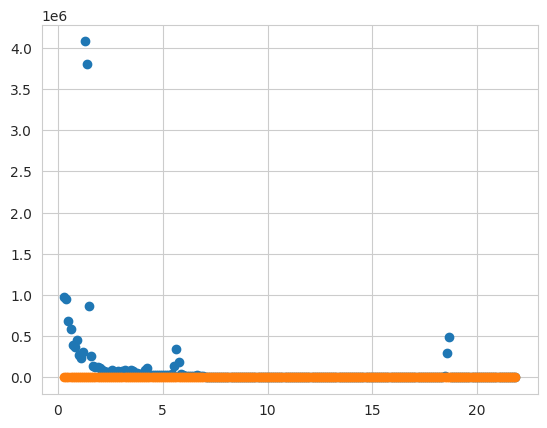

In [31]:
for i in range(len(halo['image_orientations_v'])):
    print(halo['profile_v_lum_den'][i],halo['profile_lum_den_v'][i])

    plt.scatter(halo['profile_rbins_v'][i], halo['profile_v_lum_den'][i])
    plt.scatter(halo['profile_rbins_v'][i], halo['profile_lum_den_v'][i])
    break

In [17]:
import numpy as np

def SB_integrated(r_bins, profile_lum_den_v):
    """
    Integrate luminosity density profile to get total luminosity.

    Parameters:
    -----------
    r_bins : array
        Radial bin edges
    profile_lum_den_v : array
        Luminosity density in each bin (length = len(r_bins) - 1)

    Returns:
    --------
    total_lum : float
        Total integrated luminosity
    """

    # Add 0 at the beginning of r_bins to include the innermost bin
    r_bins = np.insert(r_bins, 0, 0)
    # Calculate annular area for each bin
    # Area of annulus = π * (r_outer² - r_inner²)
    r_inner = r_bins[:-1]
    r_outer = r_bins[1:]

    areas = np.pi * (r_outer**2 - r_inner**2)

    # Total luminosity = sum of (luminosity density × area)
    total_lum = np.nansum(profile_lum_den_v * areas)

    return total_lum


# Main loop
profile_lum_den_v_list = halo['profile_lum_den_v']
profile_rbins_list = halo['profile_rbins_v']
orientations = halo['image_orientations_v']
areas = halo['profile_binarea_v']

# Store results
integrated_luminosities = []

for i in range(len(profile_lum_den_v_list)):
    orientation = orientations[i]
    lum_dens = profile_lum_den_v_list[i]
    rbins = profile_rbins_list[i]
    area = areas[i]

    total_lum = np.nansum(area * lum_dens)
    integrated_luminosities.append(total_lum)


    #print(f"Orientation {i} ({orientation}): Total Luminosity = {total_lum:.4e}")


# Convert to array if needed
integrated_luminosities = np.array(integrated_luminosities)

print(np.mean(integrated_luminosities),np.std(integrated_luminosities))

32957373.979662724 83903.58053922489


In [40]:
import matplotlib.pyplot as plt
import numpy as np

def get_mass(mass):
    """Helper function to handle mass values that could be lists or floats"""
    if isinstance(mass, list):
        return mass[0]
    elif isinstance(mass, float):
        return mass
    else:
        return mass

def plot_galaxy_smoothing_validation(halo, sim_name, halo_name, figsize=(15, 15)):
    """
    Plot smoothed galaxy shapes for stars, dark matter, and gas components.

    Parameters:
    -----------
    halo : halo object with shape data
    sim_name : str, simulation name
    halo_name : str, halo identifier
    figsize : tuple, figure size
    """

    # Get data from halo
    try:
        # Raw data
        ba_s_raw = halo['ba_s']
        ca_s_raw = halo['ca_s']
        ba_d_raw = halo['ba_d']
        ca_d_raw = halo['ca_d']
        ba_g_raw = halo['ba_g']
        ca_g_raw = halo['ca_g']

        # Raw radial bins
        rbins_s = halo['rbins_s']
        rbins_d = halo['rbins_d']
        rbins_g = halo['rbins_g']

        # Effective radius
        reff = halo['image_reffs_v'][0] if hasattr(halo['image_reffs_v'], '__len__') else halo['image_reffs_v']

        # Get filtered radial bins and smoothed functions from halo.calculate
        r_s_f = halo.calculate('r_s_f()')
        r_d_f = halo.calculate('r_d_f()')
        r_g_f = halo.calculate('r_g_f()')

        ba_s_smoothed = halo.calculate('ba_s_smoothed()')
        ca_s_smoothed = halo.calculate('ca_s_smoothed()')
        ba_d_smoothed = halo.calculate('ba_d_smoothed()')
        ca_d_smoothed = halo.calculate('ca_d_smoothed()')
        ba_g_smoothed = halo.calculate('ba_g_smoothed()')
        ca_g_smoothed = halo.calculate('ca_g_smoothed()')

        # Get values at 2*reff
        ba_s_at_2reff = ba_s_smoothed(2*reff)
        ca_s_at_2reff = ca_s_smoothed(2*reff)
        ba_d_at_2reff = ba_d_smoothed(2*reff)
        ca_d_at_2reff = ca_d_smoothed(2*reff)
        ba_g_at_2reff = ba_g_smoothed(2*reff)
        ca_g_at_2reff = ca_g_smoothed(2*reff)

    except Exception as e:
        print(f"Error accessing data for {sim_name}/{halo_name}: {e}")
        return None

    # Set up the figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)

    # Colors for each component
    colors = {
        'stars': '#0066CC',     # Blue
        'dm': '#000000',        # Black
        'gas': '#CC0000'        # Red
    }

    # Alpha values for different data types
    alpha_raw = 0.3
    alpha_filtered = 1.0

    # Create high-resolution radius array for smooth curves
    r_max = 5 * reff
    r_smooth = np.linspace(0, r_max, 200)

    # Plot ba vs r (top subplot)
    halo_id = halo_name.split('_')[1]
    ax1.set_title(f'{sim_name} / Halo {halo_id}', fontsize=16, fontweight='bold')

    # Stars
    if len(rbins_s) > 0 and len(ba_s_raw) > 0:
        # Raw data
        ax1.scatter(rbins_s, ba_s_raw, c=colors['stars'], alpha=alpha_raw, s=20, label='Stars (raw)')
        # Filtered data - find actual raw data points at filtered rbins
        if len(r_s_f) > 0:
            # Find indices of filtered radii in original rbins
            filtered_indices = [i for i, r in enumerate(rbins_s) if r in r_s_f]
            ba_s_filtered = [ba_s_raw[i] for i in filtered_indices]
            r_s_filtered_actual = [rbins_s[i] for i in filtered_indices]
            ax1.scatter(r_s_filtered_actual, ba_s_filtered, c=colors['stars'], alpha=alpha_filtered,
                       s=20, marker='s', label='Stars (filtered)')

    # Stars smoothed curve
    ba_s_smooth_vals = [ba_s_smoothed(r) for r in r_smooth]
    ax1.plot(r_smooth, ba_s_smooth_vals, color=colors['stars'],
            linewidth=3, label='Stars (smoothed)')
    # Mark value at 2*reff
    ax1.scatter([2*reff], [ba_s_at_2reff], c=colors['stars'], s=100,
               marker='*', edgecolor='black', linewidth=1, zorder=10,
               label=f'Stars @ 2R_eff = {ba_s_at_2reff:.3f}')

    # Dark matter
    if len(rbins_d) > 0 and len(ba_d_raw) > 0:
        # Raw data
        ax1.scatter(rbins_d, ba_d_raw, c=colors['dm'], alpha=alpha_raw, s=20, label='DM (raw)')
        # Filtered data - find actual raw data points at filtered rbins
        if len(r_d_f) > 0:
            filtered_indices = [i for i, r in enumerate(rbins_d) if r in r_d_f]
            ba_d_filtered = [ba_d_raw[i] for i in filtered_indices]
            r_d_filtered_actual = [rbins_d[i] for i in filtered_indices]
            ax1.scatter(r_d_filtered_actual, ba_d_filtered, c=colors['dm'], alpha=alpha_filtered,
                       s=20, marker='s', label='DM (filtered)')

    # Dark matter smoothed curve
    ba_d_smooth_vals = [ba_d_smoothed(r) for r in r_smooth]
    ax1.plot(r_smooth, ba_d_smooth_vals, color=colors['dm'],
            linewidth=3, label='DM (smoothed)')
    # Mark value at 2*reff
    ax1.scatter([2*reff], [ba_d_at_2reff], c=colors['dm'], s=100,
               marker='*', edgecolor='white', linewidth=1, zorder=10,
               label=f'DM @ 2R_eff = {ba_d_at_2reff:.3f}')

    # Gas
    if len(rbins_g) > 0 and len(ba_g_raw) > 0:
        # Raw data
        ax1.scatter(rbins_g, ba_g_raw, c=colors['gas'], alpha=alpha_raw, s=20, label='Gas (raw)')
        # Filtered data - find actual raw data points at filtered rbins
        if len(r_g_f) > 0:
            filtered_indices = [i for i, r in enumerate(rbins_g) if r in r_g_f]
            ba_g_filtered = [ba_g_raw[i] for i in filtered_indices]
            r_g_filtered_actual = [rbins_g[i] for i in filtered_indices]
            ax1.scatter(r_g_filtered_actual, ba_g_filtered, c=colors['gas'], alpha=alpha_filtered,
                       s=20, marker='s', label='Gas (filtered)')

    # Gas smoothed curve
    ba_g_smooth_vals = [ba_g_smoothed(r) for r in r_smooth]
    ax1.plot(r_smooth, ba_g_smooth_vals, color=colors['gas'],
            linewidth=3, label='Gas (smoothed)')
    # Mark value at 2*reff
    ax1.scatter([2*reff], [ba_g_at_2reff], c=colors['gas'], s=100,
               marker='*', edgecolor='black', linewidth=1, zorder=10,
               label=f'Gas @ 2R_eff = {ba_g_at_2reff:.3f}')

    # Add 2*reff reference line
    ax1.axvline(2*reff, color='gray', linestyle=':', alpha=0.7, linewidth=2,
               label=f'2×R_eff = {2*reff:.2f}')

    ax1.set_xlim(0, r_max)
    ax1.set_ylim(0, 1)
    ax1.set_xlabel('Radius', fontsize=14)
    ax1.set_ylabel('b/a', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    ax1.tick_params(axis='both', which='major', labelsize=12)

    # Plot ca vs r (bottom subplot)
    ax2.set_title('', fontsize=16)  # No title for second plot

    # Stars
    if len(rbins_s) > 0 and len(ca_s_raw) > 0:
        # Raw data
        ax2.scatter(rbins_s, ca_s_raw, c=colors['stars'], alpha=alpha_raw, s=20, label='Stars (raw)')
        # Filtered data - find actual raw data points at filtered rbins
        if len(r_s_f) > 0:
            filtered_indices = [i for i, r in enumerate(rbins_s) if r in r_s_f]
            ca_s_filtered = [ca_s_raw[i] for i in filtered_indices]
            r_s_filtered_actual = [rbins_s[i] for i in filtered_indices]
            ax2.scatter(r_s_filtered_actual, ca_s_filtered, c=colors['stars'], alpha=alpha_filtered,
                       s=20, marker='s', label='Stars (filtered)')

    # Stars smoothed curve
    ca_s_smooth_vals = [ca_s_smoothed(r) for r in r_smooth]
    ax2.plot(r_smooth, ca_s_smooth_vals, color=colors['stars'],
            linewidth=3, label='Stars (smoothed)')
    # Mark value at 2*reff
    ax2.scatter([2*reff], [ca_s_at_2reff], c=colors['stars'], s=100,
               marker='*', edgecolor='black', linewidth=1, zorder=10,
               label=f'Stars @ 2R_eff = {ca_s_at_2reff:.3f}')

    # Dark matter
    if len(rbins_d) > 0 and len(ca_d_raw) > 0:
        # Raw data
        ax2.scatter(rbins_d, ca_d_raw, c=colors['dm'], alpha=alpha_raw, s=20, label='DM (raw)')
        # Filtered data - find actual raw data points at filtered rbins
        if len(r_d_f) > 0:
            filtered_indices = [i for i, r in enumerate(rbins_d) if r in r_d_f]
            ca_d_filtered = [ca_d_raw[i] for i in filtered_indices]
            r_d_filtered_actual = [rbins_d[i] for i in filtered_indices]
            ax2.scatter(r_d_filtered_actual, ca_d_filtered, c=colors['dm'], alpha=alpha_filtered,
                       s=20, marker='s', label='DM (filtered)')

    # Dark matter smoothed curve
    ca_d_smooth_vals = [ca_d_smoothed(r) for r in r_smooth]
    ax2.plot(r_smooth, ca_d_smooth_vals, color=colors['dm'],
            linewidth=3, label='DM (smoothed)')
    # Mark value at 2*reff
    ax2.scatter([2*reff], [ca_d_at_2reff], c=colors['dm'], s=100,
               marker='*', edgecolor='white', linewidth=1, zorder=10,
               label=f'DM @ 2R_eff = {ca_d_at_2reff:.3f}')

    # Gas
    if len(rbins_g) > 0 and len(ca_g_raw) > 0:
        # Raw data
        ax2.scatter(rbins_g, ca_g_raw, c=colors['gas'], alpha=alpha_raw, s=20, label='Gas (raw)')
        # Filtered data - find actual raw data points at filtered rbins
        if len(r_g_f) > 0:
            filtered_indices = [i for i, r in enumerate(rbins_g) if r in r_g_f]
            ca_g_filtered = [ca_g_raw[i] for i in filtered_indices]
            r_g_filtered_actual = [rbins_g[i] for i in filtered_indices]
            ax2.scatter(r_g_filtered_actual, ca_g_filtered, c=colors['gas'], alpha=alpha_filtered,
                       s=20, marker='s', label='Gas (filtered)')

    # Gas smoothed curve
    ca_g_smooth_vals = [ca_g_smoothed(r) for r in r_smooth]
    ax2.plot(r_smooth, ca_g_smooth_vals, color=colors['gas'],
            linewidth=3, label='Gas (smoothed)')
    # Mark value at 2*reff
    ax2.scatter([2*reff], [ca_g_at_2reff], c=colors['gas'], s=100,
               marker='*', edgecolor='black', linewidth=1, zorder=10,
               label=f'Gas @ 2R_eff = {ca_g_at_2reff:.3f}')

    # Add 2*reff reference line
    ax2.axvline(2*reff, color='gray', linestyle=':', alpha=0.7, linewidth=2,
               label=f'2×R_eff = {2*reff:.2f}')

    ax2.set_xlim(0, r_max)
    ax2.set_ylim(0, 1)
    ax2.set_xlabel('Radius', fontsize=14)
    ax2.set_ylabel('c/a', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    ax2.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout()
    return fig

# To use in your loop, update your processing code to:
# r_s_f, r_d_f, r_g_f = halo.calculate('r_s_f'), halo.calculate('r_d_f'), halo.calculate('r_g_f')
# ba_s_smoothed, ca_s_smoothed = halo.calculate('ba_s_smoothed()'),halo.calculate('ca_s_smoothed()')
# ba_d_smoothed, ca_d_smoothed = halo.calculate('ba_d_smoothed()'),halo.calculate('ca_d_smoothed()')
# ba_g_smoothed, ca_g_smoothed = halo.calculate('ba_g_smoothed()'),halo.calculate('ca_g_smoothed()')

# Then add this line after processing each halo:
# plot_galaxy_smoothing_validation(halo, sim_name, halo_name)
# plt.show()

In [46]:
#loop through halos and plot ba vs ca for dark matter, stars, and gas
shape_dict = {}

def get_mass(mass):
    #if mass is a list, return the first element
    if isinstance(mass, list):
        return mass[0]
    #if mass is a float, return it
    elif isinstance(mass, float):
        return mass

def valid_shape_value(value):
    if value < 0 or value > 1:
        return np.nan
    else:
        return value


for sim in sims:
    sim_name = str(sim.basename)
    print(f"Simulation {sim_name}")

    # Initialize dictionary for this sim if it doesn't exist
    if sim_name not in shape_dict:
        shape_dict[sim_name] = {}


    if len(sim.timesteps) > 1:
        timestep = sim.timesteps[-1]
    elif len(sim.timesteps) == 1:
        timestep = sim.timesteps[0]
    halos = timestep.halos[:50]

    #for Massive merians, only process largest halo
    if sim_name.startswith('r') and not sim_name.startswith('rogue'):
        #print(sim)
        max_halo = None
        max_stars = 0
        for i,halo in enumerate(halos):
            n_stars = halo['n_star'][0]
            if n_stars > max_stars:
                max_stars = n_stars
                max_halo = i
        halos = [halos[max_halo]]
        print('removing all halos except {} from sim {}'.format(halos[0].basename.split('_')[1],sim_name))
    elif sim_name.startswith('h'):
        print(f'removing halo 0 from sim {sim_name}')
        halos = halos[1:]

    for _, halo in enumerate(halos):
        halo_name = halo.basename
        halo_ref = f'{sim_name}/%/{halo_name}'
        hid = halo_name.split('_')[1]

        # Skip if we've already processed this halo
        if halo_ref in shape_dict[sim_name].keys():
            print(f"Skipping halo {hid} - already processed")
            continue

        #print(halo['n_star'][0])
        if halo['n_star'][0] < 4000:
            continue

        #halo_images = halo['halo_images_v']

        image_reffs = halo['image_reffs_v']
        reff = image_reffs[0]
        image_orientations = halo['image_orientations_v']
        #mass density images
        mass_images = halo['halo_images_rho_stars']

        Rhalf = halo['Rhalf_v']
        # isophote_params = halo['isophote_parameters']
        stellar_mass = get_mass(halo['M_star'])
        reffs = np.array(image_reffs)
        #get ba_s,ca_s,ba_d,ca_d,ba_g,ca_g
        ba_s,ca_s,ba_d,ca_d,ba_g,ca_g = halo['ba_s'],halo['ca_s'],halo['ba_d'],halo['ca_d'],halo['ba_g'],halo['ca_g']
        rbins_s,rbins_d,rbins_g = halo['rbins_s'], halo['rbins_d'], halo['rbins_g']
        #save value at closest bin to reff
        ba_s_smoothed, ca_s_smoothed = halo.calculate('ba_s_smoothed()'),halo.calculate('ca_s_smoothed()')
        ba_d_smoothed, ca_d_smoothed = halo.calculate('ba_d_smoothed()'),halo.calculate('ca_d_smoothed()')
        ba_g_smoothed, ca_g_smoothed = halo.calculate('ba_g_smoothed()'),halo.calculate('ca_g_smoothed()')
        ba_s = ba_s_smoothed(2*reff)
        ca_s = ca_s_smoothed(2*reff)
        ba_d = ba_d_smoothed(2*reff)
        ca_d = ca_d_smoothed(2*reff)
        ba_g = ba_g_smoothed(2*reff)
        ca_g = ca_g_smoothed(2*reff)

        ba_s = valid_shape_value(ba_s)
        ca_s = valid_shape_value(ca_s)
        ba_d = valid_shape_value(ba_d)
        ca_d = valid_shape_value(ca_d)
        ba_g = valid_shape_value(ba_g)
        ca_g = valid_shape_value(ca_g)


        #make sure are physical values (between 0 and 1), if not, replace with nan
        if ba_s > 1 or ba_s < 0:
            ba_s = np.nan

        r_edge = halo['r_edge']
        r1 = halo['r1']
        #save to dict
        halo_dict = {'ba_s':ba_s,'ca_s':ca_s,'ba_d':ba_d,'ca_d':ca_d, 'ba_g':ba_g,'ca_g':ca_g,'r_edge':r_edge,'M_star':stellar_mass, 'reff':reff,'r1':r1}
        shape_dict[sim_name][halo_name] = halo_dict
        #plot_galaxy_smoothing_validation(halo, sim_name, halo_name)



Simulation cptmarvel.cosmo25cmb.4096g5HbwK1BH
Simulation elektra.cosmo25cmb.4096g5HbwK1BH
Simulation h148.cosmo50PLK.3072g3HbwK1BH
removing halo 0 from sim h148.cosmo50PLK.3072g3HbwK1BH
Simulation h229.cosmo50PLK.3072gst5HbwK1BH
removing halo 0 from sim h229.cosmo50PLK.3072gst5HbwK1BH
Simulation h242.cosmo50PLK.3072gst5HbwK1BH
removing halo 0 from sim h242.cosmo50PLK.3072gst5HbwK1BH
Simulation h329.cosmo50PLK.3072gst5HbwK1BH
removing halo 0 from sim h329.cosmo50PLK.3072gst5HbwK1BH
Simulation r1023.romulus25.3072g1HsbBH
removing all halos except 2 from sim r1023.romulus25.3072g1HsbBH
Simulation r431.romulus25.3072g1HsbBH
removing all halos except 1 from sim r431.romulus25.3072g1HsbBH
Simulation r442.romulus25.3072g1HsbBH
removing all halos except 1 from sim r442.romulus25.3072g1HsbBH
Simulation r468.romulus25.3072g1HsbBH
removing all halos except 1 from sim r468.romulus25.3072g1HsbBH
Simulation r488.romulus25.3072g1HsbBH
removing all halos except 1 from sim r488.romulus25.3072g1HsbBH
Si

In [47]:
shape_dict

{'cptmarvel.cosmo25cmb.4096g5HbwK1BH': {'halo_1': {'ba_s': array(0.89723479),
   'ca_s': array(0.33999102),
   'ba_d': array(0.93891139),
   'ca_d': array(0.56949607),
   'ba_g': array(0.96058452),
   'ca_g': array(0.49033085),
   'r_edge': 1.7599711742466002,
   'M_star': 39700200.0,
   'reff': np.float64(1.1737169918792998),
   'r1': 2.2304587113077607},
  'halo_2': {'ba_s': array(0.88163059),
   'ca_s': array(0.22368398),
   'ba_d': array(0.96724957),
   'ca_d': array(0.47307434),
   'ba_g': array(0.98236791),
   'ca_g': array(0.24042363),
   'r_edge': 0.6272295599494697,
   'M_star': 10892300.0,
   'reff': np.float64(1.8142444942887506),
   'r1': 0.8483007764861384},
  'halo_3': {'ba_s': array(0.63733503),
   'ca_s': array(0.39014116),
   'ba_d': array(0.7747901),
   'ca_d': array(0.49681549),
   'ba_g': array(0.47767561),
   'ca_g': array(0.18947198),
   'r_edge': 0.286502523921191,
   'M_star': 6212150.0,
   'reff': np.float64(0.7625752408907607),
   'r1': 0.8274228323442948},
  

39700200.0
10892300.0
6212150.0
8924150.0
8376650.0
None
1999770.0
2510400.0
181081000.0
53379300.0
30931900.0
44450800.0
28569000.0
24204500.0
2819100.0
None
1537550000.0
1018020000.0
292621000.0
224723000.0
159906000.0
18763200.0
91711500.0
16623300.0
70736200.0
41930000.0
27945500.0
68042100.0
57033500.0
564309000.0
23650100.0
155327000.0
16782200.0
52283800.0
542349000.0
539125000.0
167850000.0
20797300.0
16850600.0
19518900.0
18619200.0
37002400.0
1006370000.0
1017540000.0
1390000000.0
1187870000.0
538182000.0
804487000.0
966007000.0
746480000.0
361651000.0
534832000.0
258427000.0
590646000.0
737072000.0
275015000.0
1308710000.0
322965000.0
298427000.0
372337000.0
372149000.0
291390000.0
2021830000.0
298058000.0
302888000.0
335078000.0
391508000.0
49496300.0
93835500.0
119051000.0
111121000.0
122918000.0
94338000.0
73124500.0
91882500.0
67750700.0
76095000.0
263483000.0
80407900.0
320303000.0
63250000.0
60511200.0
1199580000.0
1042840.0
84682800.0
94420500.0
28503800.0
62158200.0


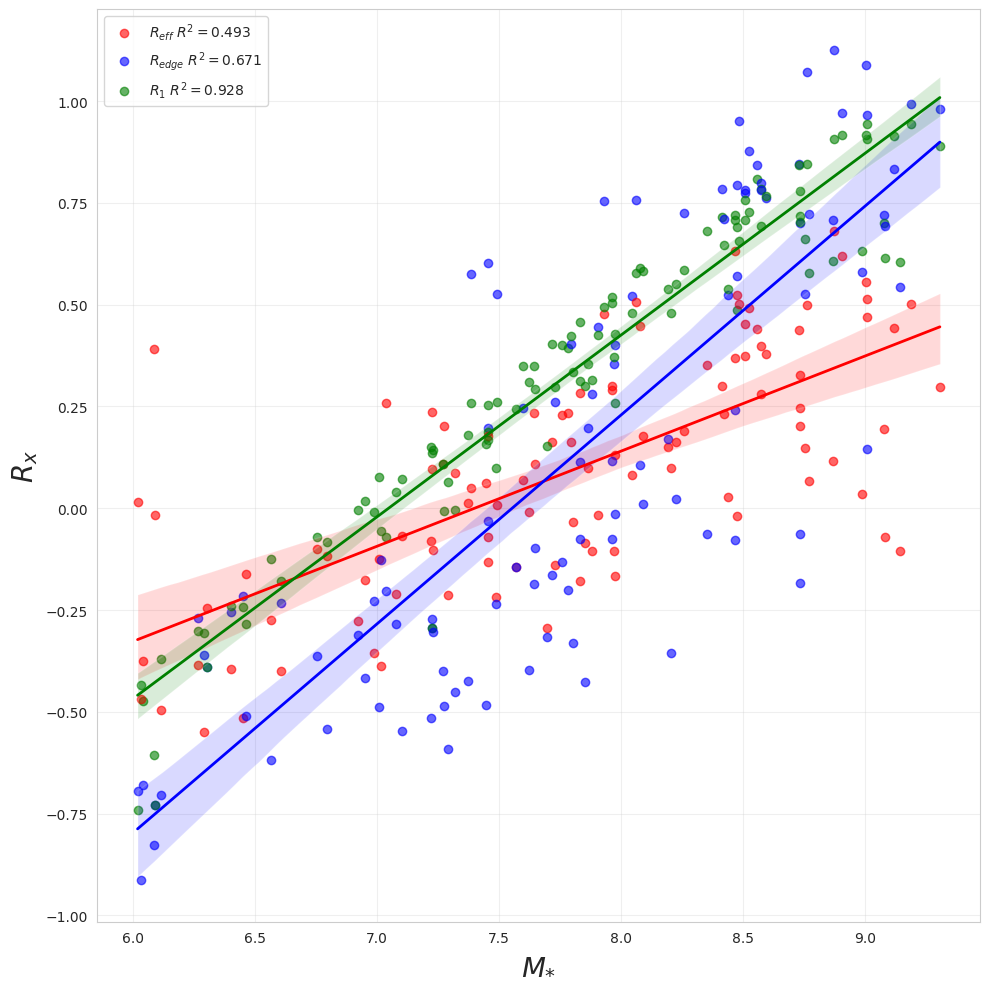

In [49]:


import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

fig1,ax1 = plt.subplots(figsize = (10,10))

# Initialize lists to collect data for regression
mstar_data = []
reff_data = []
r_edge_data = []
r1_data = []

i=0
for sim in shape_dict:
    for halo in shape_dict[sim]:
        #print(sim,halo)
        halo_dict = shape_dict[sim][halo]
        ba_s,ca_s,ba_d,ca_d,ba_g,ca_g = halo_dict['ba_s'],halo_dict['ca_s'],halo_dict['ba_d'],halo_dict['ca_d'],halo_dict['ba_g'],halo_dict['ca_g']
        reff = halo_dict['reff']

        reff = halo_dict['reff']
        r_edge = halo_dict['r_edge']
        r1 = halo_dict['r1']
        Mstar = get_mass(halo_dict['M_star'])
        print(Mstar)
        if Mstar == None:
            continue

        # Collect data for regression (only if values are valid)
        if Mstar > 0 and reff > 0 and r_edge > 0 and r1 > 0:
            mstar_data.append(Mstar)
            reff_data.append(reff)
            r_edge_data.append(r_edge)
            r1_data.append(r1)

        ax1.scatter(np.log10(Mstar),np.log10(reff),color='r',label = r'$R_{eff}$', alpha=0.6)
        ax1.scatter(np.log10(Mstar),np.log10(r_edge),color='b',label = r'$R_{edge}$', alpha=0.6)
        ax1.scatter(np.log10(Mstar),np.log10(r1),color='g',label = r'$R_{1}$', alpha=0.6)
        #only add legend during first loop
        if i ==0:
            ax1.legend()
        i = i+1

# Convert to numpy arrays for easier handling
mstar_data = np.array(mstar_data)
reff_data = np.array(reff_data)
r_edge_data = np.array(r_edge_data)
r1_data = np.array(r1_data)

log_mstar = np.log10(mstar_data)
log_reff = np.log10(reff_data)
log_r_edge = np.log10(r_edge_data)
log_r1 = np.log10(r1_data)

# Add regression lines in log space using seaborn
# Note: seaborn regplot automatically handles log-transformed data when axes are in log scale
sns.regplot(x=log_mstar, y=log_reff, ax=ax1, scatter=False, color='r',
           label=r'$R_{eff}$ fit', line_kws={'linewidth': 2})
sns.regplot(x=log_mstar, y=log_r_edge, ax=ax1, scatter=False, color='b',
           label=r'$R_{edge}$ fit', line_kws={'linewidth': 2})
sns.regplot(x=log_mstar, y=log_r1, ax=ax1, scatter=False, color='g',
           label=r'$R_{1}$ fit', line_kws={'linewidth': 2})

# Calculate and print regression statistics
from scipy import stats

# Perform linear regression in log space


slope_reff, intercept_reff, r_value_reff, p_value_reff, std_err_reff = stats.linregress(log_mstar, log_reff)
slope_r_edge, intercept_r_edge, r_value_r_edge, p_value_r_edge, std_err_r_edge = stats.linregress(log_mstar, log_r_edge)
slope_r1, intercept_r1, r_value_r1, p_value_r1, std_err_r1 = stats.linregress(log_mstar, log_r1)

print(f"Reff: slope = {slope_reff:.3f} ± {std_err_reff:.3f}, R² = {r_value_reff**2:.3f}")
print(f"R_edge: slope = {slope_r_edge:.3f} ± {std_err_r_edge:.3f}, R² = {r_value_r_edge**2:.3f}")
print(f"R1: slope = {slope_r1:.3f} ± {std_err_r1:.3f}, R² = {r_value_r1**2:.3f}")

#put Rsquared values on ax1
labels = [rf'$R_{{eff}}$ $R^2 = {r_value_reff**2:.3f}$',rf'$R_{{edge}}$ $R^2 = {r_value_r_edge**2:.3f}$' ,rf'$R_{1}$ $R^2 =  {r_value_r1**2:.3f}$']
ax1.legend(labels)

ax1.set_xlabel('$M_{*}$',size = 20)
ax1.set_ylabel('$R_{x}$',size = 20)




# Add grid for better readability of log-log plot
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

{'cptmarvel.cosmo25cmb.4096g5HbwK1BH': {'halo_1': {'ba_s': array(0.89723479), 'ca_s': array(0.33999102), 'ba_d': array(0.93891139), 'ca_d': array(0.56949607), 'ba_g': array(0.96058452), 'ca_g': array(0.49033085), 'r_edge': 1.7599711742466002, 'M_star': 39700200.0, 'reff': np.float64(1.1737169918792998), 'r1': 2.2304587113077607}, 'halo_2': {'ba_s': array(0.88163059), 'ca_s': array(0.22368398), 'ba_d': array(0.96724957), 'ca_d': array(0.47307434), 'ba_g': array(0.98236791), 'ca_g': array(0.24042363), 'r_edge': 0.6272295599494697, 'M_star': 10892300.0, 'reff': np.float64(1.8142444942887506), 'r1': 0.8483007764861384}, 'halo_3': {'ba_s': array(0.63733503), 'ca_s': array(0.39014116), 'ba_d': array(0.7747901), 'ca_d': array(0.49681549), 'ba_g': array(0.47767561), 'ca_g': array(0.18947198), 'r_edge': 0.286502523921191, 'M_star': 6212150.0, 'reff': np.float64(0.7625752408907607), 'r1': 0.8274228323442948}, 'halo_5': {'ba_s': array(0.92566947), 'ca_s': array(0.70853289), 'ba_d': array(0.941972

/tmp/ipykernel_2220556/3478242796.py:79: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(self.data[f'{x_key}_{comp}'][mask], self.data[f'{y_key}_{comp}'][mask],


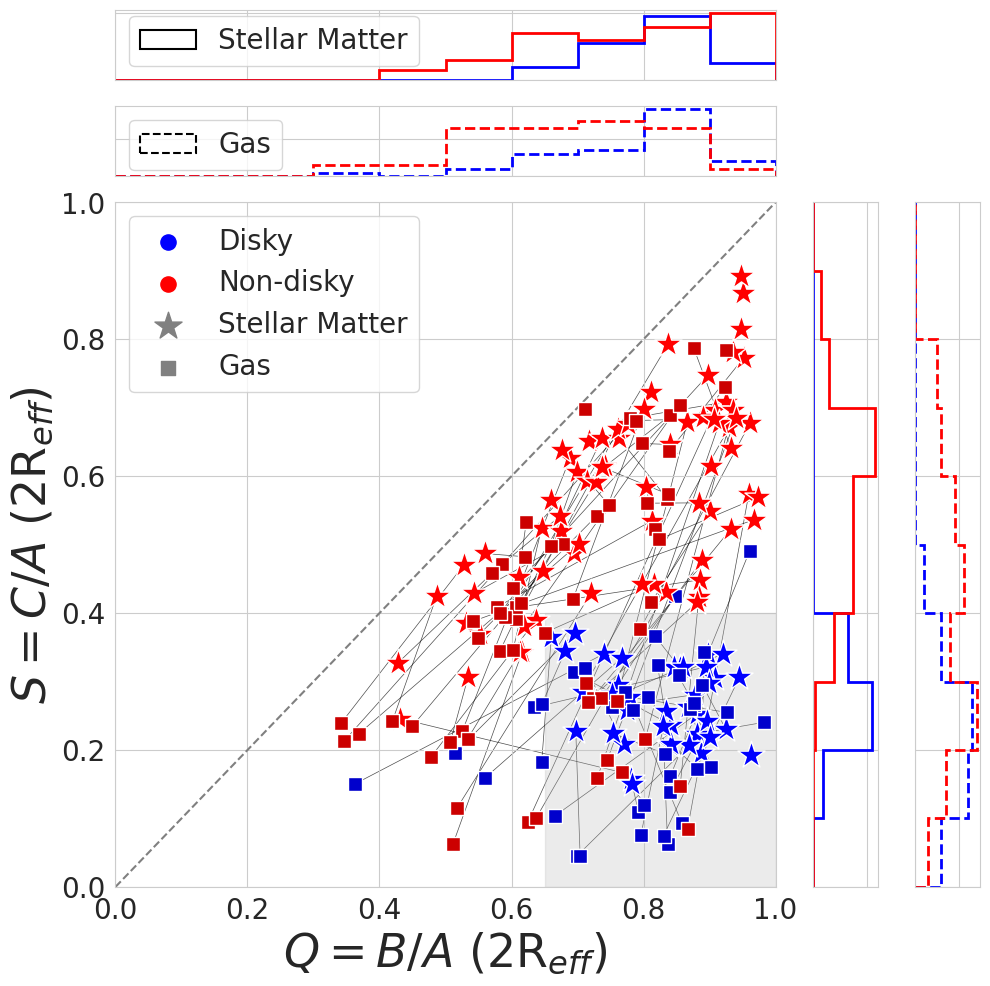

In [62]:
# Extract data from your shape_dict into numpy arrays
def prepare_data_from_shape_dict(shape_dict):
    """
    Convert shape_dict to numpy arrays suitable for GeneralPlotter
    """
    # Collect all data points
    all_data = []
    sim_names = []
    halo_names = []

    for sim_name, halos in shape_dict.items():
        for halo_name, halo_data in halos.items():
            all_data.append(halo_data)
            sim_names.append(sim_name)
            halo_names.append(halo_name)

    # Convert to numpy arrays
    n_galaxies = len(all_data)
    data_arrays = {}
    print(all_data)
    # Extract shape parameters for each component
    for key in ['ba', 'ca']:  # b/a and c/a ratios
        for comp in ['s', 'd', 'g']:  # stars, dark matter, gas
            data_key = f'{key}_{comp}'
            print(data_key)
            if data_key in all_data[0]:  # Check if this component exists
                data_arrays[f'{key.lower()}_{comp}'] = np.array([d[data_key] for d in all_data])
    for d in all_data:
        print(d['M_star'])
    # Add other useful data
    data_arrays['M_star'] = np.array([d['M_star'] for d in all_data])
    data_arrays['reff'] = np.array([d['reff'] for d in all_data])
    data_arrays['sim_names'] = np.array(sim_names)
    data_arrays['halo_names'] = np.array(halo_names)

    # Add reff_multi (you can adjust this based on your analysis)
    data_arrays['reff_multi'] = 2  # Since you're using 2*reff

    return data_arrays

# Prepare your data
print(shape_dict)
data_arrays = prepare_data_from_shape_dict(shape_dict)

print(data_arrays)

# Extract shape parameters for creating masks
B_s = data_arrays['ba_s']  # b/a ratio for stars
C_s = data_arrays['ca_s']  # c/a ratio for stars

# Create disk/elliptical masks
C_thresh = 0.4
B_thresh = 0.65
disks_mask = (C_s < C_thresh) & (B_s > B_thresh)
ellip_mask = ~disks_mask

# Set up masks dictionary
masks = {
    'disks': disks_mask,
    'ellipticals': ellip_mask
}

# Set up labels
labels = {
    'disks': 'Disky',
    'ellipticals': 'Non-disky',
    'ba': 'Q',
    'ca': 'S'
}

# Set up colors
colors = {
    'disks': 'blue',
    'ellipticals': 'red'
}

# Create plotter instance with all three components (stars, dark matter, gas)
plotter = GeneralPlotter(
    data=data_arrays,
    masks=masks,
    labels=labels,
    colors=colors,
    components=['s', 'g']  # stars, dark matter, gas
)

# Plot b/a vs c/a for all components
plotter.plot_data_with_masks('ba', 'ca', show_scatter=True, show_lines=True,
                           filename='ba_vs_ca_all_components.png')



In [ ]:
#print galaxy names and halo numbers for case when galaxy appears nondisky and gas is disky?
#so gas shape ca_g < 0.4 and ba_g > 0.65, while ca_s > 0.4 or ba_s < 0.65

B_g = data_arrays['ba_g']  # b/a ratio for stars
C_g = data_arrays['ca_g']  # c/a ratio for stars

# Create disk/elliptical masks
C_thresh = 0.4
B_thresh = 0.65
disk_gas_mask = (C_g < C_thresh) & (B_g > B_thresh)

#combine disk gas mask and ellipse mask
mask = disk_gas_mask & ellip_mask
print(data_arrays['sim_names'][mask],data_arrays['halo_names'][mask])


In [72]:
import numpy as np
from collections import defaultdict

# Your existing code
B_g = data_arrays['ba_g']  # b/a ratio for stars
C_g = data_arrays['ca_g']  # c/a ratio for stars

# Create disk/elliptical masks
C_thresh = 0.4
B_thresh = 0.65
disk_gas_mask = (C_g < C_thresh) & (B_g > B_thresh)

# Combine disk gas mask and ellipse mask
mask = disk_gas_mask & ellip_mask

# Get filtered data
sim_names = data_arrays['sim_names'][mask]
halo_names = data_arrays['halo_names'][mask]

print("Raw output:")
print(sim_names, halo_names)
print("\n" + "="*50 + "\n")

# Create organized output
def create_shortened_format(sim_names, halo_names):
    """
    Convert simulation and halo names to shortened format
    Example: 'h229.cosmo50PLK.3072gst5HbwK1BH' + 'halo_2' -> '<h229 2>'
    """
    shortened_list = []

    for sim_name, halo_name in zip(sim_names, halo_names):
        # Extract simulation prefix (part before first dot)
        sim_prefix = sim_name.split('.')[0]

        # Extract halo number (part after 'halo_')
        halo_number = halo_name.replace('halo_', '')

        # Create shortened format
        shortened = f"{sim_prefix} {halo_number}"
        shortened_list.append(shortened)

    return shortened_list

# Generate shortened format
shortened_entries = create_shortened_format(sim_names, halo_names)



# Option 1: Simple list
print("Shortened format list:")
for i, entry in enumerate(shortened_entries, 1):
    print(f"{entry}")




Raw output:
['h229.cosmo50PLK.3072gst5HbwK1BH' 'h229.cosmo50PLK.3072gst5HbwK1BH'
 'h242.cosmo50PLK.3072gst5HbwK1BH' 'h242.cosmo50PLK.3072gst5HbwK1BH'
 'h242.cosmo50PLK.3072gst5HbwK1BH' 'h242.cosmo50PLK.3072gst5HbwK1BH'
 'h329.cosmo50PLK.3072gst5HbwK1BH' 'r634.romulus25.3072g1HsbBH'
 'r918.romulus25.3072g1HsbBH' 'r968.romulus25.3072g1HsbBH'
 'rogue.cosmo25cmb.4096g5HbwK1BH' 'rogue.cosmo25cmb.4096g5HbwK1BH'
 'storm.cosmo25cmb.4096g5HbwK1BH'] ['halo_2' 'halo_5' 'halo_8' 'halo_10' 'halo_11' 'halo_20' 'halo_7'
 'halo_1' 'halo_1' 'halo_3' 'halo_5' 'halo_11' 'halo_19']


Shortened format list:
h229 2
h229 5
h242 8
h242 10
h242 11
h242 20
h329 7
r634 1
r918 1
r968 3
rogue 5
rogue 11
storm 19


['h229.cosmo50PLK.3072gst5HbwK1BH' 'h229.cosmo50PLK.3072gst5HbwK1BH'
 'h242.cosmo50PLK.3072gst5HbwK1BH' 'h242.cosmo50PLK.3072gst5HbwK1BH'
 'h242.cosmo50PLK.3072gst5HbwK1BH' 'h242.cosmo50PLK.3072gst5HbwK1BH'
 'h329.cosmo50PLK.3072gst5HbwK1BH' 'r634.romulus25.3072g1HsbBH'
 'r918.romulus25.3072g1HsbBH' 'r968.romulus25.3072g1HsbBH'
 'rogue.cosmo25cmb.4096g5HbwK1BH' 'rogue.cosmo25cmb.4096g5HbwK1BH'
 'storm.cosmo25cmb.4096g5HbwK1BH'] ['halo_2' 'halo_5' 'halo_8' 'halo_10' 'halo_11' 'halo_20' 'halo_7'
 'halo_1' 'halo_1' 'halo_3' 'halo_5' 'halo_11' 'halo_19']


/tmp/ipykernel_2220556/3478242796.py:79: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(self.data[f'{x_key}_{comp}'][mask], self.data[f'{y_key}_{comp}'][mask],


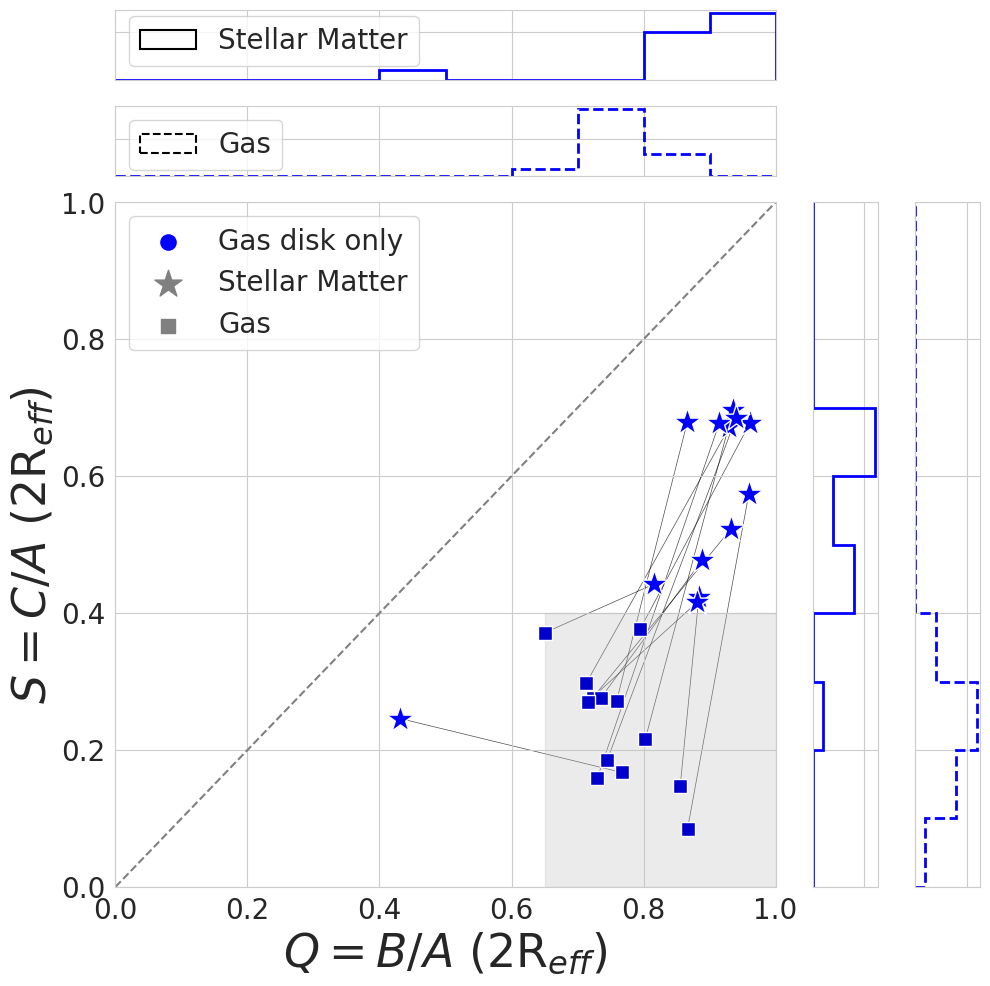

In [68]:


#make new plot showing just the galaxies in this new mask:
masks = {'disk_gas_only':mask}
colors = {'disk_gas_only': 'b'}
labels = {'disk_gas_only': 'Gas disk only',
              'ba': 'Q',
    'ca': 'S'}


# Create plotter instance with all three components (stars, dark matter, gas)
plotter = GeneralPlotter(
    data=data_arrays,
    masks=masks,
    labels=labels,
    colors=colors,
    components=['s', 'g']  # stars, dark matter, gas
)

# Plot b/a vs c/a for all components
plotter.plot_data_with_masks('ba', 'ca', show_scatter=True, show_lines=True,
                           filename='ba_vs_ca_all_gas_disk_special.png')





In [35]:
data_arrays.keys()

dict_keys(['ba_s', 'ba_d', 'ba_g', 'ca_s', 'ca_d', 'ca_g', 'M_star', 'reff', 'sim_names', 'halo_names', 'reff_multi'])

In [1]:

import pickle
import os
import numpy as np

# Define pickle filename using a consistent pattern
pickle_filename = 'ellipse_data.pickle'

# Check if pickle file exists and load it if it does
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        ellipse_dict = pickle.load(f)
    print(f"Loaded existing data from {pickle_filename}")
else:
    ellipse_dict = {}
    print(f"Starting with fresh data")
    



Loaded existing data from ellipse_data.pickle


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression


class GeneralPlotter:
    def __init__(self, data, masks,
                 labels, colors,
                 components = None):
        self.data = data
        self.masks = masks
        self.labels = labels
        self.colors = colors
        self.legend_fontsize = 20
        self.axis_fontsize = 33
        self.tick_fontsize = 20
        self.point_size = 120
        self.bin_count = 10
        self.plot_KF_data = False
        self.plot_regression = False

        # Define component configurations
        self.component_configs = {
            's': {'name': 'Stellar Matter', 'marker': '*', 'size_multiplier': 3.5, 'color_adjustment': 1.0},
            'd': {'name': 'Dark Matter', 'marker': 'o', 'size_multiplier': 1.0, 'color_adjustment': 1.5},
            'g': {'name': 'Gas', 'marker': 's', 'size_multiplier': 0.8, 'color_adjustment': 1.2}
        }

        # Set which components to plot (default to all available)
        if components is None:
            # Auto-detect available components by checking data keys
            available_components = set()
            for key in self.data.keys():
                if '_' in key:
                    suffix = key.split('_')[-1]
                    if suffix in self.component_configs:
                        available_components.add(suffix)
            self.components = sorted(list(available_components))
        else:
            self.components = components

        # Validate components
        for comp in self.components:
            if comp not in self.component_configs:
                raise ValueError(f"Invalid component '{comp}'. Must be one of: {list(self.component_configs.keys())}")

        reff = data['reff_multi']
        if reff != 1:
            self.suptitle = rf'{reff}R$_{{eff}}$'
        else:
            self.suptitle = rf'R$_{{eff}}$'

    def lighten_color(self, color: str, amount: float = 0.5) -> str:
        """
        Lightens the given color by multiplying (1-luminosity) by the given amount.
        """
        import colorsys
        try:
            c = plt.matplotlib.colors.cnames[color]
        except:
            c = color
        c = colorsys.rgb_to_hls(*plt.matplotlib.colors.to_rgb(c))
        return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

    def plot_main(self, ax: plt.Axes, x_key: str, y_key: str, show_scatter: bool = True,
                  show_lines: bool = False, link_sims: bool = False):
        size = self.point_size

        for mask_name, mask in self.masks.items():
            color = self.colors[mask_name]

            # Plot each component
            for comp in self.components:
                config = self.component_configs[comp]
                comp_color = self.lighten_color(color, config['color_adjustment'])

                if show_scatter:
                    ax.scatter(self.data[f'{x_key}_{comp}'][mask], self.data[f'{y_key}_{comp}'][mask],
                             c=comp_color, marker=config['marker'],
                             s=size*config['size_multiplier'], alpha=1, zorder=10,
                             edgecolors='white')

            # Draw lines connecting components if requested
            if show_lines or not show_scatter:
                if not link_sims:
                    for i in np.where(mask)[0]:
                        # Draw lines between consecutive components
                        for j in range(len(self.components) - 1):
                            comp1, comp2 = self.components[j], self.components[j+1]
                            line_color = 'k' if show_scatter else color
                            line_width = 0.5 if show_scatter else 1

                            ax.plot([self.data[f'{x_key}_{comp1}'][i], self.data[f'{x_key}_{comp2}'][i]],
                                   [self.data[f'{y_key}_{comp1}'][i], self.data[f'{y_key}_{comp2}'][i]],
                                   zorder=0, lw=line_width, c=line_color, alpha=0.7)

                if link_sims:
                    # Link lines across feedback types for sims with the same name
                    sims = np.copy(self.data['sims'])
                    unique_sims = np.unique(sims)

                    for sim in unique_sims:
                        indices = []
                        for i in range(len(sims)):
                            if sims[i] == sim:
                                indices.append(i)

                        sidm_index = []
                        cdm_index = []
                        for index in indices:
                            if self.data['feedback_type'][index] == 'BWMDC':
                                sidm_index.append(index)
                            elif self.data['feedback_type'][index] == 'SBMarvel':
                                cdm_index.append(index)
                            else:
                                raise ValueError(f'Error: feedback type not recognized: {self.data["feedback_type"][index]}')

                        # Plot lines for each component
                        for comp in self.components:
                            ax.plot([self.data[f'{x_key}_{comp}'][sidm_index], self.data[f'{x_key}_{comp}'][cdm_index]],
                                   [self.data[f'{y_key}_{comp}'][sidm_index], self.data[f'{y_key}_{comp}'][cdm_index]],
                                   zorder=0, lw=0.5, c='k', alpha=0.7)

        # Plot shaded region where x > 0.6 and y < 0.4
        ax.fill_between([0.65, 1], 0, 0.4, color='0.75', alpha=0.3)

    def plot_histograms(self, ax_histx_list, ax_histy_list,
                        x_key: str, y_key: str):
        bins = np.linspace(0, 1, self.bin_count + 1)
        lw = 2
        linestyles = ['-', '--', '-.', ':']

        for mask_name, mask in self.masks.items():
            color = self.colors[mask_name]
            density = False

            # Plot histograms for each component (limited by available axes)
            for i, comp in enumerate(self.components):
                # Use available histogram axes, cycling if necessary
                if ax_histx_list:
                    ax_x = ax_histx_list[i % len(ax_histx_list)]
                    ax_x.hist(self.data[f'{x_key}_{comp}'][mask], bins=bins, density=density,
                             histtype='step', color=color, lw=lw, ls=linestyles[i % len(linestyles)], alpha=1)

                if ax_histy_list:
                    ax_y = ax_histy_list[i % len(ax_histy_list)]
                    ax_y.hist(self.data[f'{y_key}_{comp}'][mask], bins=bins, density=density,
                             histtype='step', orientation='horizontal', color=color, lw=lw,
                             ls=linestyles[i % len(linestyles)], alpha=1)

    def plot_data_with_masks(self, x_key: str, y_key: str, show_lines: bool = False,
                             show_scatter: bool = True, filename: str = None, link_sims = False):
        from matplotlib.patches import Ellipse
        import matplotlib.transforms as transforms

        # Calculate grid layout based on number of components
        n_components = len(self.components)
        fig = plt.figure(figsize=(10, 10), dpi=100)

        # Ensure we have exactly 5 height and width ratios for a 5x5 grid
        # Top rows for histograms, bottom 3 rows for main plot
        height_ratios = [1, 1, 3, 3, 3]  # Always 5 ratios
        width_ratios = [3, 3, 3, 1, 1]   # Always 5 ratios

        gs = gridspec.GridSpec(5, 5, height_ratios=height_ratios, width_ratios=width_ratios)

        ax_main = plt.subplot(gs[2:5, 0:3])

        # Create histogram axes for components (limited to available space)
        ax_histx_list = []
        ax_histy_list = []

        # Top histograms (x-direction) - use rows 0 and 1
        for i in range(min(n_components, 2)):
            ax_histx_list.append(plt.subplot(gs[i, 0:3], sharex=ax_main))

        # Side histograms (y-direction) - use columns 3 and 4
        for i in range(min(n_components, 2)):
            ax_histy_list.append(plt.subplot(gs[2:5, 3+i], sharey=ax_main))

        self.plot_main(ax_main, x_key, y_key, show_scatter, show_lines, link_sims)
        self.plot_histograms(ax_histx_list, ax_histy_list, x_key, y_key)

        # Set up legends, labels, and grid
        for mask_name, color in self.colors.items():
            if show_scatter:
                ax_main.scatter(-1, -1, c=color, marker='o', s=self.point_size,
                               label=f'{self.labels[mask_name]}')

        # Add component legend
        if show_scatter:
            for comp in self.components:
                config = self.component_configs[comp]
                ax_main.scatter(-1, -1, c='gray', marker=config['marker'],
                               s=self.point_size*config['size_multiplier'],
                               label=config['name'])

        ax_main.legend(loc='upper left', fontsize=self.legend_fontsize)
        ax_main.set_xlabel(rf'${self.labels[x_key]} = {x_key[0].upper()}/A$ ({self.suptitle})',
                          fontsize=self.axis_fontsize)
        ax_main.set_ylabel(rf'${self.labels[y_key]} = {y_key[0].upper()}/A$ ({self.suptitle})',
                          fontsize=self.axis_fontsize)
        ax_main.set_xlim([0, 1])
        ax_main.set_ylim([0, 1])
        ax_main.plot([0, 1], [0, 1], c='0.5', linestyle='--')
        ax_main.tick_params(which='both', labelsize=self.tick_fontsize)

        # Remove tick marks for histograms
        for ax_list in [ax_histx_list, ax_histy_list]:
            for ax in ax_list:
                ax.tick_params(axis='both', which='both', bottom=False, top=False,
                              left=False, right=False, labelbottom=False, labelleft=False)

        # Add legends for histograms
        linestyles = ['-', '--', '-.', ':']
        for i, comp in enumerate(self.components):
            if i < len(ax_histx_list):
                config = self.component_configs[comp]
                ax_histx_list[i].hist([], bins=1, density=True, histtype='step', color='k',
                                     lw=1.5, ls=linestyles[i % len(linestyles)],
                                     label=config['name'])
                ax_histx_list[i].legend(fontsize=self.legend_fontsize)

        plt.tight_layout()
        if filename:
            plt.savefig(filename, bbox_inches='tight', pad_inches=.1, dpi=300)
        else:
            plt.show()

    def calculate_shape_diff(self):
        """Calculate shape differences between components"""
        for key in ['b', 'c']:  # Focus on b and c ratios
            for i in range(len(self.components)):
                for j in range(i+1, len(self.components)):
                    comp1, comp2 = self.components[i], self.components[j]
                    diff = self.data[f'{key.upper()}_{comp1}'] / self.data[f'{key.upper()}_{comp2}']
                    label = f'{key.upper()}_{comp1}/{key.upper()}_{comp2}'

                    for mask_name, mask in self.masks.items():
                        print(f'{self.labels[mask_name]} galaxies: {label} mean: {np.mean(diff[mask]):.2f}, '
                              f'std: {np.std(diff[mask]):.2f}')

                        # Also print individual component stats
                        d1 = self.data[f'{key.upper()}_{comp1}'][mask]
                        d2 = self.data[f'{key.upper()}_{comp2}'][mask]
                        print(f'{key.upper()}_{comp1}: {np.mean(d1):.2f} +/- {np.std(d1):.2f}')
                        print(f'{key.upper()}_{comp2}: {np.mean(d2):.2f} +/- {np.std(d2):.2f}')
                        print('---')

In [4]:
#sims = sims[0:1]

In [4]:
ellipse_dict['cptmarvel.cosmo25cmb.4096g5HbwK1BH']['cptmarvel.cosmo25cmb.4096g5HbwK1BH/%/halo_2']

{'x000y000': array([0.05604496, 0.01985306, 0.01985306]),
 'x000y030': array([0.16887573, 0.15063087,        nan]),
 'x000y060': array([0.49937097, 0.50023143,        nan]),
 'x000y090': array([0.84334118, 0.76250749, 0.76250749]),
 'x000y120': array([0.53821039, 0.49815862,        nan]),
 'x000y150': array([0.20344577, 0.14858225,        nan]),
 'x000y180': array([0.03076476, 0.03076476, 0.03076476]),
 'x000y210': array([0.16908194, 0.15050622,        nan]),
 'x000y240': array([0.49518504, 0.49447299,        nan]),
 'x000y270': array([0.84950365, 0.76291842, 0.76291842]),
 'x000y300': array([0.53726143, 0.49841503,        nan]),
 'x000y330': array([0.18798866, 0.14793649,        nan]),
 'x030y000': array([0.01267105, 0.12088093, 0.12088093]),
 'x030y030': array([0.19684223, 0.1630872 ,        nan]),
 'x030y060': array([0.5850219, 0.5341146,       nan]),
 'x030y090': array([0.84272579, 0.76318144, 0.73572728]),
 'x030y120': array([0.56499279, 0.5573458 ,        nan]),
 'x030y150': arra

Simulation cptmarvel.cosmo25cmb.4096g5HbwK1BH
Processing halo 0 with 205466 stars


In [5]:
for key in ellipse_dict['cptmarvel.cosmo25cmb.4096g5HbwK1BH'][4]:
    print(1 - ellipse_dict['cptmarvel.cosmo25cmb.4096g5HbwK1BH'][4][key][0])

0.9345798050044246
0.86192930871715
0.7866353738473382
0.7270751516242374
0.808654094856304
0.9066283504697307
0.9348852064858102
0.8621789619089394
0.787115165653213
0.72733138598938
0.8085954006817391
0.907539827592396
0.9257148957821869
0.9103755907422466
0.8010164493483128
0.7271381385157683
0.7856417631166246
0.8714951132734455
0.9253364298546146
0.9104964838036893
0.8013292814802155
0.7273676796030084
0.7858265452746487
0.8713937089312015
0.9067313865072357
0.8858265726226193
0.7883296310832916
0.7273114171398879
0.7541013156716097
0.8135218357579104
0.9065372830000357
0.88591877641954
0.78869015562913
0.727415352021874
0.7538635476395785
0.8137787684121802
0.7954983801278441
0.7961525876940492
0.7680823998062767
0.7270814060732691
0.7236742385589638
0.7696332926178358
0.7959810256415509
0.7968375598643924
0.7679636026645041
0.7273294345549737
0.72366446085497
0.7705680300771375
0.8231249296955043
0.8268992609287745
0.7790776036901382
0.7265417309066975
0.7297187371681914
0.77352

In [ ]:
#I accidentally added some halos that we don't want to keep, so let's remove them

# for any sim that starts with 'r*' and is not 'rogue', keep only the halo with the most star particles (not interested in sattelites of dwarfs)
#get star particles count with tangos.get_simulation(sim).timesteps[0].halos[halo_id]['n_star'][0]
for sim in ellipse_dict.keys():
    if sim.startswith('r') and not sim.startswith('rogue'):
        #print(sim)
        max_halo = None
        max_stars = 0
        for halo_id in ellipse_dict[sim].keys():
            n_stars = tangos.get_simulation(sim).timesteps[0].halos[halo_id]['n_star'][0]
            if n_stars > max_stars:
                max_stars = n_stars
                max_halo = halo_id
        #print(max_halo)
        hids_to_remove = []
        for halo_id in ellipse_dict[sim].keys():
            if halo_id != max_halo:
                #dry run
                print(f"would remove halo {halo_id} from {sim}, with N stars {tangos.get_simulation(sim).timesteps[0].halos[halo_id]['n_star'][0]}, max halo {max_halo} with N stars {max_stars}")
                hids_to_remove.append(halo_id)
        #remove halos
        for halo_id in hids_to_remove:
                del ellipse_dict[sim][halo_id]

#similarly for and sim that starts with 'h', remove halo 0, if it exists (MW type galaxy, not a dwarf)
for sim in ellipse_dict.keys():
    if sim.startswith('h'):
        #print(sim)
        if 0 in ellipse_dict[sim].keys():
            #dry run
            try:
                print(f"would remove halo 0 from {sim}, with stellar mass {tangos.get_simulation(sim).timesteps[0].halos[0]['M_star']:.2e}")
            except:
                print(f"would remove halo 0 from {sim}")

            del ellipse_dict[sim][0]

In [ ]:

#save to pickle file
with open('ellipse_data.pickle', 'wb') as f:
    pickle.dump(ellipse_dict, f)

In [12]:
print(ellipse_dict['h329.cosmo50PLK.3072gst5HbwK1BH'].keys())

dict_keys([7, 9, 10, 12, 0, 6])


In [12]:
#load ellipse_dict from pickle file
import pickle
with open('ellipse_data_v_stars.pickle', 'rb') as f:
    ellipse_dict = pickle.load(f)

In [7]:
k = -2


isophote_param = isophote_params[k]
print(isophote_param)
for i in range(len(isophote_param)):
    
    print(f'sma = {isophote_param[i][0]:.2f}, eps = {isophote_param[i][1]:.2f}, grad_err = {isophote_param[i][3]:.2f},intens = {isophote_param[i][6]:.2f}, rms = {isophote_param[i][7]:.2f}, intensity/rms = {isophote_param[i][6]/isophote_param[i][7]:.2f}',isophote_param[i][6]/isophote_param[i][7] > 0.5 and isophote_param[i][6] > 10)
    #print if intens/rms > 1 and intens > 200




[[np.float64(91.38521904761885), np.float64(0.536540461764474), np.float64(2.5719728668261888), np.float64(0.09864291649019191), np.float64(497.9690472441495), np.float64(502.7325617029669), np.float64(33637.32445540552), np.float64(9983.615122992764)], [np.float64(133.9265756746022), np.float64(0.5422420986541285), np.float64(2.585893161381694), np.float64(0.09220488905651462), np.float64(478.8040239110333), np.float64(502.4793380638708), np.float64(22293.05487370639), np.float64(7286.261601215679)], [np.float64(138.65339307760033), np.float64(0.5473880155525157), np.float64(2.608566117035578), np.float64(0.08844866701654053), np.float64(478.53854111008025), np.float64(502.0527194924418), np.float64(21341.414951530798), np.float64(6056.155607628338)], [np.float64(143.38021048059846), np.float64(0.540875712546391), np.float64(2.633709577395208), np.float64(0.09469925057634432), np.float64(477.75546769873966), np.float64(501.5313183369988), np.float64(19672.09437586851), np.float64(5117

In [13]:
import numpy as np
import pickle
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator, Rbf

def interpolate_orientations(halo_ellipses, reff_multipliers=[2, 3, 4],
                             interpolation_method='linear', coordinate_system='angles'):
    """
    Function that interpolates ellipticity values for arbitrary viewing angles.
    Handles periodic boundary conditions.
    """
    # Function to extract angles from orientation string
    def parse_orientation(orientation):
        try:
            x_angle = int(orientation[1:4])  # Rotation around x-axis in degrees
            y_angle = int(orientation[5:8])  # Rotation around y-axis in degrees
            return x_angle, y_angle
        except (ValueError, IndexError):
            print(f"Invalid orientation format: {orientation}")
            return None, None

    # Function to convert angles to 3D unit vector if using vector coordinates
    def angles_to_vector(x_angle, y_angle):
        x_rad = np.radians(x_angle)
        y_rad = np.radians(y_angle)

        # Start with vector pointing along z-axis (0, 0, -1)
        # Rotate around y-axis (affects x and z)
        vx = np.sin(y_rad)
        vy = 0
        vz = -np.cos(y_rad)

        # Rotate around x-axis (affects y and z)
        new_vy = vy * np.cos(x_rad) - vz * np.sin(x_rad)
        new_vz = vy * np.sin(x_rad) + vz * np.cos(x_rad)

        return [vx, new_vy, new_vz]

    # Prepare data points and values with periodic boundary handling
    original_points = []
    extended_points = []  # Will include periodic boundary points
    original_values = {i: [] for i in range(len(reff_multipliers))}
    extended_values = {i: [] for i in range(len(reff_multipliers))}

    # First collect all original data points
    for orientation, ellipticities in halo_ellipses.items():
        # Skip non-orientation keys
        if not (orientation.startswith('x') and 'y' in orientation):
            continue

        x_angle, y_angle = parse_orientation(orientation)
        if x_angle is None:
            continue

        # Store original point
        if coordinate_system == 'vectors':
            point = angles_to_vector(x_angle, y_angle)
        else:  # 'angles' is default
            point = [x_angle, y_angle]

        original_points.append(point)

        # Store original ellipticity values
        for i, eps in enumerate(ellipticities):
            if i < len(reff_multipliers):
                original_values[i].append(float(eps))

    # Now create extended dataset with periodic boundaries
    extended_points = original_points.copy()
    for i in range(len(reff_multipliers)):
        extended_values[i] = original_values[i].copy()

    # Handle periodicity by adding mirrored points
    if coordinate_system == 'angles':
        for idx, point in enumerate(original_points):
            x_angle, y_angle = point

            # Add points for x-periodicity (0° = 180°)
            if x_angle == 0:
                new_point = [180, y_angle]
                extended_points.append(new_point)
                for i in range(len(reff_multipliers)):
                    extended_values[i].append(original_values[i][idx])
            elif x_angle == 180:
                new_point = [0, y_angle]
                extended_points.append(new_point)
                for i in range(len(reff_multipliers)):
                    extended_values[i].append(original_values[i][idx])

            # Add points for y-periodicity (0° = 360°)
            if y_angle == 0:
                new_point = [x_angle, 360]
                extended_points.append(new_point)
                for i in range(len(reff_multipliers)):
                    extended_values[i].append(original_values[i][idx])
            elif y_angle == 360 or y_angle == 359:
                new_point = [x_angle, 0]
                extended_points.append(new_point)
                for i in range(len(reff_multipliers)):
                    extended_values[i].append(original_values[i][idx])

            # Add points for corner cases
            if (x_angle == 0 and y_angle == 0):
                new_point = [180, 360]
                extended_points.append(new_point)
                for i in range(len(reff_multipliers)):
                    extended_values[i].append(original_values[i][idx])
            elif (x_angle == 180 and y_angle == 0):
                new_point = [0, 360]
                extended_points.append(new_point)
                for i in range(len(reff_multipliers)):
                    extended_values[i].append(original_values[i][idx])
            elif (x_angle == 0 and (y_angle == 360 or y_angle == 359)):
                new_point = [180, 0]
                extended_points.append(new_point)
                for i in range(len(reff_multipliers)):
                    extended_values[i].append(original_values[i][idx])
            elif (x_angle == 180 and (y_angle == 360 or y_angle == 359)):
                new_point = [0, 0]
                extended_points.append(new_point)
                for i in range(len(reff_multipliers)):
                    extended_values[i].append(original_values[i][idx])

    #filter out nan data points:
    # Filter out NaN values before creating interpolators
    for i in range(len(reff_multipliers)):
        if len(extended_values[i]) == 0:
            continue

        # Convert to numpy arrays for efficient filtering
        points_array = np.array(extended_points)
        values_array = np.array(extended_values[i])

        # Create boolean mask for non-NaN values
        valid_mask = ~np.isnan(values_array)

        # Apply mask to filter out NaN values
        points_array = points_array[valid_mask]
        values_array = values_array[valid_mask]

        # Store the filtered arrays back for interpolation
        extended_points_filtered = points_array
        extended_values[i] = values_array


    # Create interpolators based on selected method using filtered dataset
    interpolators = {}
    fallback_interpolators = {}
    
    for i in range(len(reff_multipliers)):
        if len(extended_values[i]) == 0:
            continue

        points_array = np.array(extended_points_filtered)
        values_array = np.array(extended_values[i])

        if interpolation_method == 'rbf':
            if coordinate_system == 'vectors':
                interpolators[i] = Rbf(
                    points_array[:, 0], points_array[:, 1], points_array[:, 2],
                    values_array, function='multiquadric'
                )
            else:
                interpolators[i] = Rbf(
                    points_array[:, 0], points_array[:, 1],
                    values_array, function='multiquadric'
                )
        elif interpolation_method == 'nearest':
            interpolators[i] = NearestNDInterpolator(points_array, values_array)
        else:  # 'linear' is default
            interpolators[i] = LinearNDInterpolator(points_array, values_array)
            fallback_interpolators[i] = NearestNDInterpolator(points_array, values_array)

    # Define the interpolation function with periodic boundary handling
    def interpolate(x_angle, y_angle, reff_index=0):
        """
        Estimate ellipticity at arbitrary viewing angles with periodic boundaries.
        """
        # Normalize angles to the periodic domain
        if x_angle > 180:
            x_angle = x_angle % 180
        if y_angle > 360:
            y_angle = y_angle % 360

        if reff_index not in interpolators:
            raise ValueError(f"No data for reff_index {reff_index} (multiplier={reff_multipliers[reff_index]})")

        # Interpolate based on selected method and coordinate system
        if interpolation_method == 'rbf':
            if coordinate_system == 'vectors':
                vx, vy, vz = angles_to_vector(x_angle, y_angle)
                return float(interpolators[reff_index](vx, vy, vz))
            else:
                return float(interpolators[reff_index](x_angle, y_angle))
        else:
            if coordinate_system == 'vectors':
                point = angles_to_vector(x_angle, y_angle)
            else:
                point = [x_angle, y_angle]

            result = interpolators[reff_index](point)

            # For linear interpolation, use fallback if out of convex hull
            if interpolation_method == 'linear' and np.isnan(result):
                result = fallback_interpolators[reff_index](point)

            return float(result)

    return interpolate, reff_multipliers

# Loading function remains the same
def load_and_process_halo_data(sim_name=None, halo_id=None, pickle_filename='ellipse_data.pickle'):
    """Load ellipse data from the pickle file for a specific halo."""
    with open(pickle_filename, 'rb') as f:
        ellipse_dict = pickle.load(f)

    if sim_name is None:
        sim_name = list(ellipse_dict.keys())[0]
    if sim_name not in ellipse_dict:
        raise ValueError(f"Simulation '{sim_name}' not found")

    if halo_id is None:
        halo_id = list(ellipse_dict[sim_name].keys())[0]
    if halo_id not in ellipse_dict[sim_name]:
        raise ValueError(f"Halo ID {halo_id} not found")

    return ellipse_dict[sim_name][halo_id]

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np

def plot_ellipticity_comparison(halo_data, interpolate_func,sim,halo, reff_index=0, multiplier=2):
    """
    Plot a comparison of original ellipticity values vs. interpolated values.
    Handles periodic boundary conditions for smooth visualization.
    """
    # Extract original data points and values
    original_x = []
    original_y = []
    original_values = []

    for orientation, ellipticities in halo_data.items():
        if not (orientation.startswith('x') and 'y' in orientation):
            continue

        try:
            x_angle = int(orientation[1:4])
            y_angle = int(orientation[5:8])
            original_x.append(x_angle)
            original_y.append(y_angle)
            original_values.append(float(ellipticities[reff_index]))
        except (ValueError, IndexError, KeyError):
            pass

    # Create grid of interpolated values
    x_angles = np.arange(0, 181, 1)  # Limited from 0 to 180
    y_angles = np.arange(0, 361, 1)  # Limited from 0 to 360
    X, Y = np.meshgrid(x_angles, y_angles)
    Z = np.zeros_like(X, dtype=float)

    # Calculate interpolated values for each grid point
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            try:
                Z[i, j] = interpolate_func(X[i, j], Y[i, j], reff_index)
            except ValueError:
                Z[i, j] = np.nan

    # Find min and max values for consistent color scaling
    all_values = np.concatenate([np.array(original_values), Z.flatten()])
    all_values = all_values[~np.isnan(all_values)]
    vmin = 0.03
    vmax = 0.9
    norm = Normalize(vmin=vmin, vmax=vmax)

    # Create the figure
    f = plt.figure(figsize=(16, 8))
    # Add vertical line at x = 0 with label
    plt.axvline(x=90, color='white', linestyle='--', linewidth=2)
    plt.axhline(y=90, color='white', linestyle='--', linewidth=2)
    plt.axvline(x=270, color='white', linestyle='--', linewidth=2)
    #plt.text(2, 10, 'edge-on', rotation=90, verticalalignment='bottom')
    # Plot the interpolated heatmap
    heatmap = plt.pcolormesh(Y, X, Z, shading='auto', cmap='viridis', norm=norm)
    cbar = plt.colorbar(label='Ellipticity')

    # Overlay original data points with black outlines
    scatter = plt.scatter(original_y, original_x, c=original_values, s=100,
                         edgecolors='black', linewidths=1.5, cmap='viridis',
                         norm=norm, marker='o', zorder=10)

    # Set plot limits exactly as requested
    plt.ylim(0, 180)
    plt.xlim(0, 360)

    # Set ticks every 30 degrees on both axes
    plt.yticks(np.arange(0, 181, 30))
    plt.xticks(np.arange(0, 361, 30))



    # Add labels and title
    plt.xlabel('Y Angle (degrees)', fontsize=12)
    plt.ylabel('X Angle (degrees)', fontsize=12)
    plt.title(f'Ellipticity Values at {multiplier}*Reff', fontsize=14)

    # Add grid
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    #save
    #plt.savefig(f'figures/{sim}.{halo}.ellipticity_interpolation_{multiplier}*Reff.png', dpi=300)
    #plt.close(f)

    return plt

In [34]:
ellipse_dict['elektra.cosmo25cmb.4096g5HbwK1BH'][3]

{'x000y000': array([0.53144394, 0.52788625, 0.56504389]),
 'x000y030': array([0.50060434, 0.49199396, 0.53827252]),
 'x000y060': array([0.31084228, 0.28769913, 0.33791282]),
 'x000y090': array([0.18878345, 0.25151441, 0.3057714 ]),
 'x000y120': array([0.21495707, 0.19376617, 0.24713479]),
 'x000y150': array([0.46390519, 0.45317062, 0.51429654]),
 'x000y180': array([0.53146182, 0.5276431 , 0.56520782]),
 'x000y210': array([0.50026539, 0.49183409, 0.53862794]),
 'x000y240': array([0.3102884 , 0.28723684, 0.33776546]),
 'x000y270': array([0.18878851, 0.25182353, 0.30601987]),
 'x000y300': array([0.21506855, 0.19379336, 0.24721718]),
 'x000y330': array([0.46428114, 0.45292734, 0.51499048]),
 'x030y000': array([0.54579113, 0.55783333, 0.58897683]),
 'x030y030': array([0.49867006, 0.49742862, 0.55609893]),
 'x030y060': array([0.27976071, 0.25231344, 0.26306746]),
 'x030y090': array([0.1887274 , 0.25143688, 0.30607767]),
 'x030y120': array([0.34155267, 0.37134158, 0.4066902 ]),
 'x030y150': a

Simulation: m11d_res7100, Halo ID: m11d_res7100/%/halo_1


/tmp/ipykernel_3569993/478111105.py:206: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(result)


Simulation: m11d_res7100, Halo ID: m11d_res7100/%/halo_2
Simulation: m11d_res7100, Halo ID: m11d_res7100/%/halo_4
Simulation: m11b_res2100, Halo ID: m11b_res2100/%/halo_1
Simulation: m11e_res7100, Halo ID: m11e_res7100/%/halo_1
Simulation: m11e_res7100, Halo ID: m11e_res7100/%/halo_2
Simulation: m11h_res7100, Halo ID: m11h_res7100/%/halo_1
Simulation: m11i_res7100, Halo ID: m11i_res7100/%/halo_1
Simulation: m11q_res880, Halo ID: m11q_res880/%/halo_1
Simulation: m11q_res880, Halo ID: m11q_res880/%/halo_2
Simulation: m11q_res880, Halo ID: m11q_res880/%/halo_3
Simulation: m11q_res880, Halo ID: m11q_res880/%/halo_4
Simulation: m11q_res880, Halo ID: m11q_res880/%/halo_5
Simulation: m11q_res880, Halo ID: m11q_res880/%/halo_6


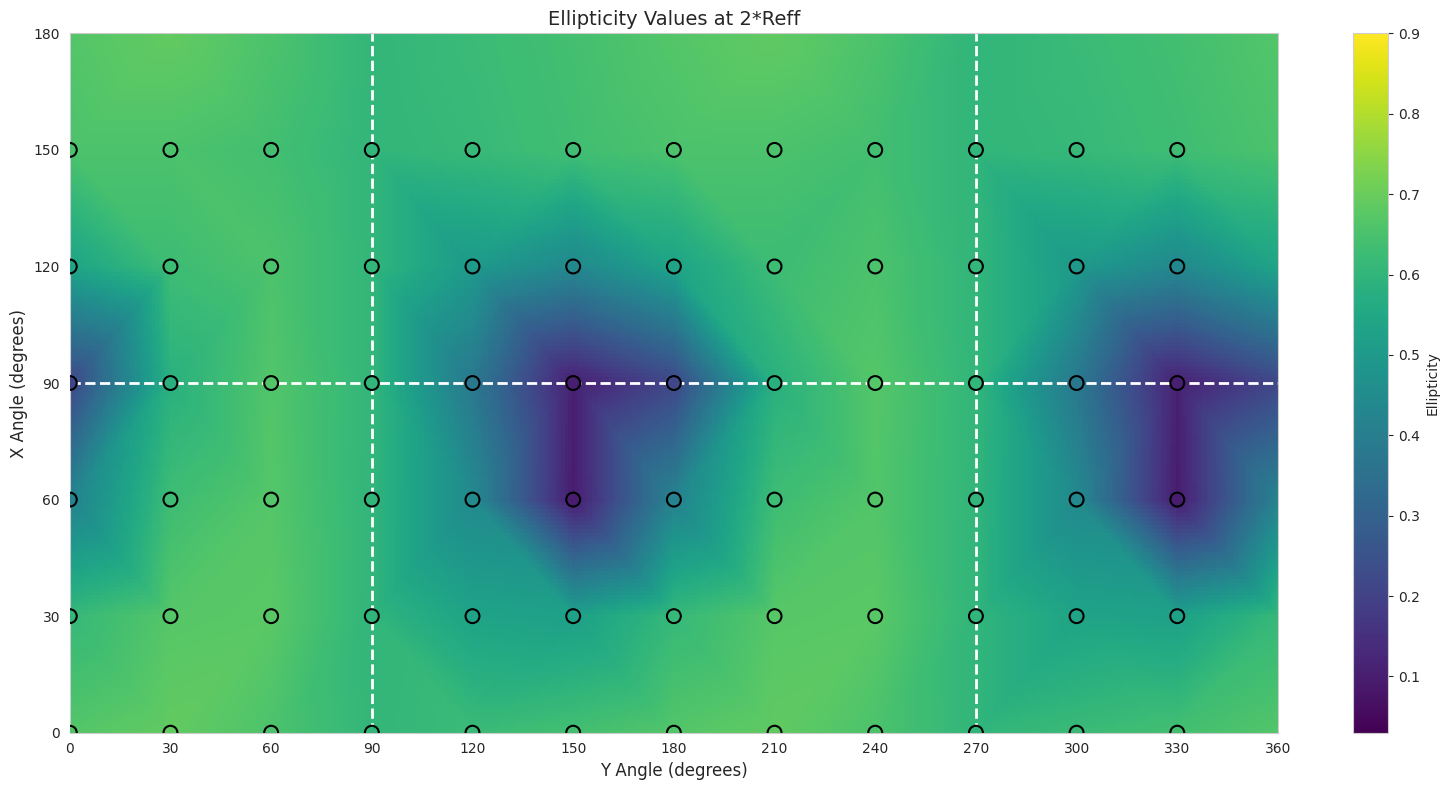

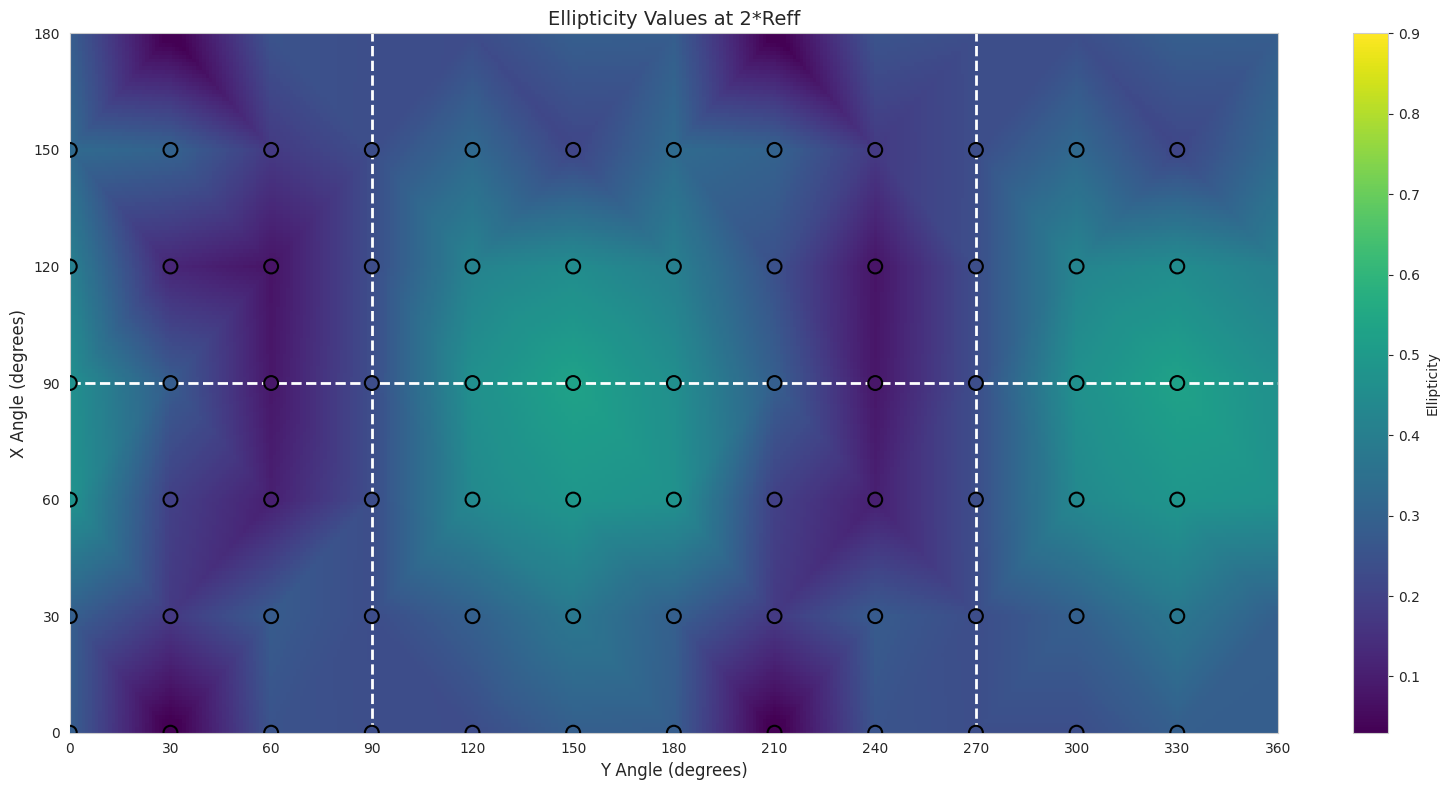

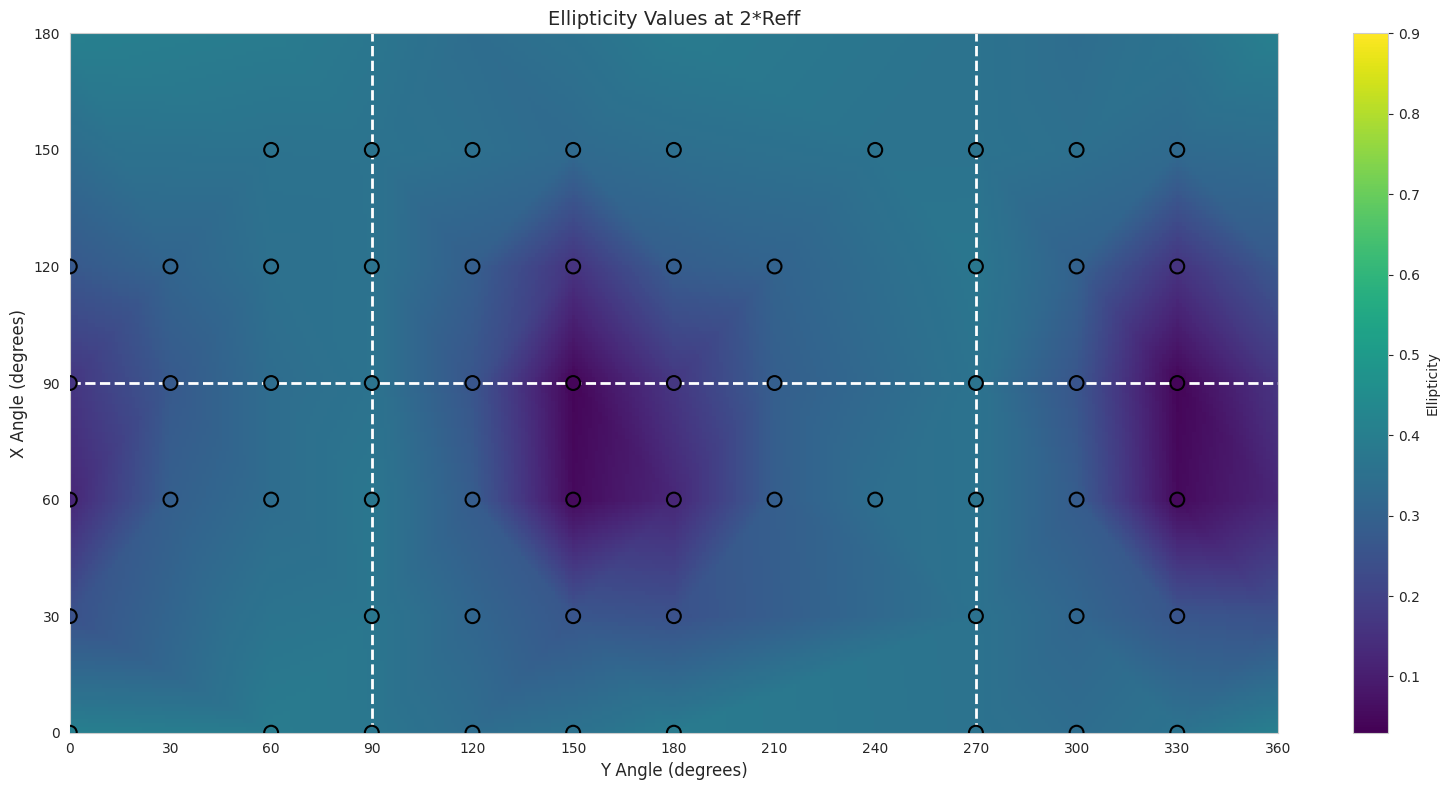

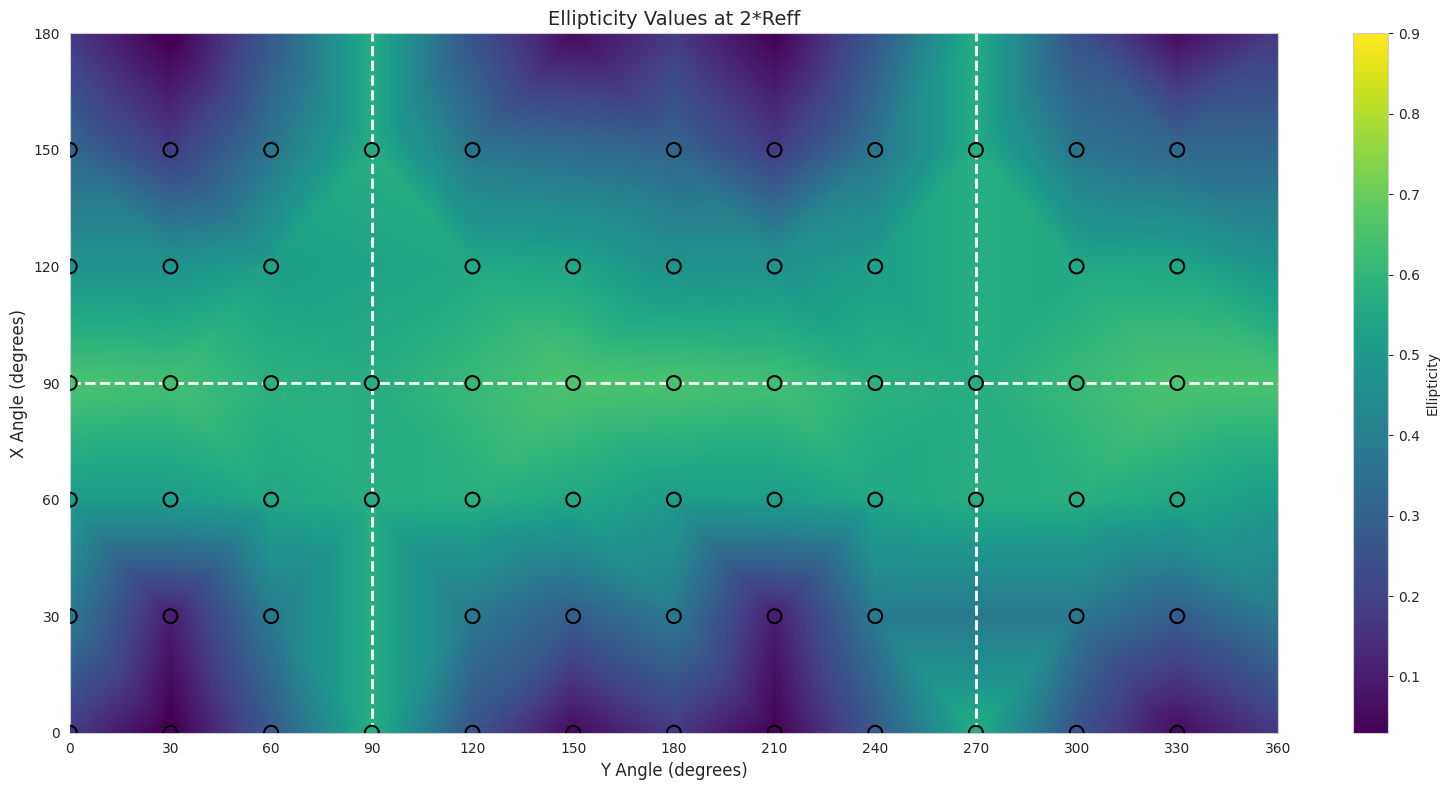

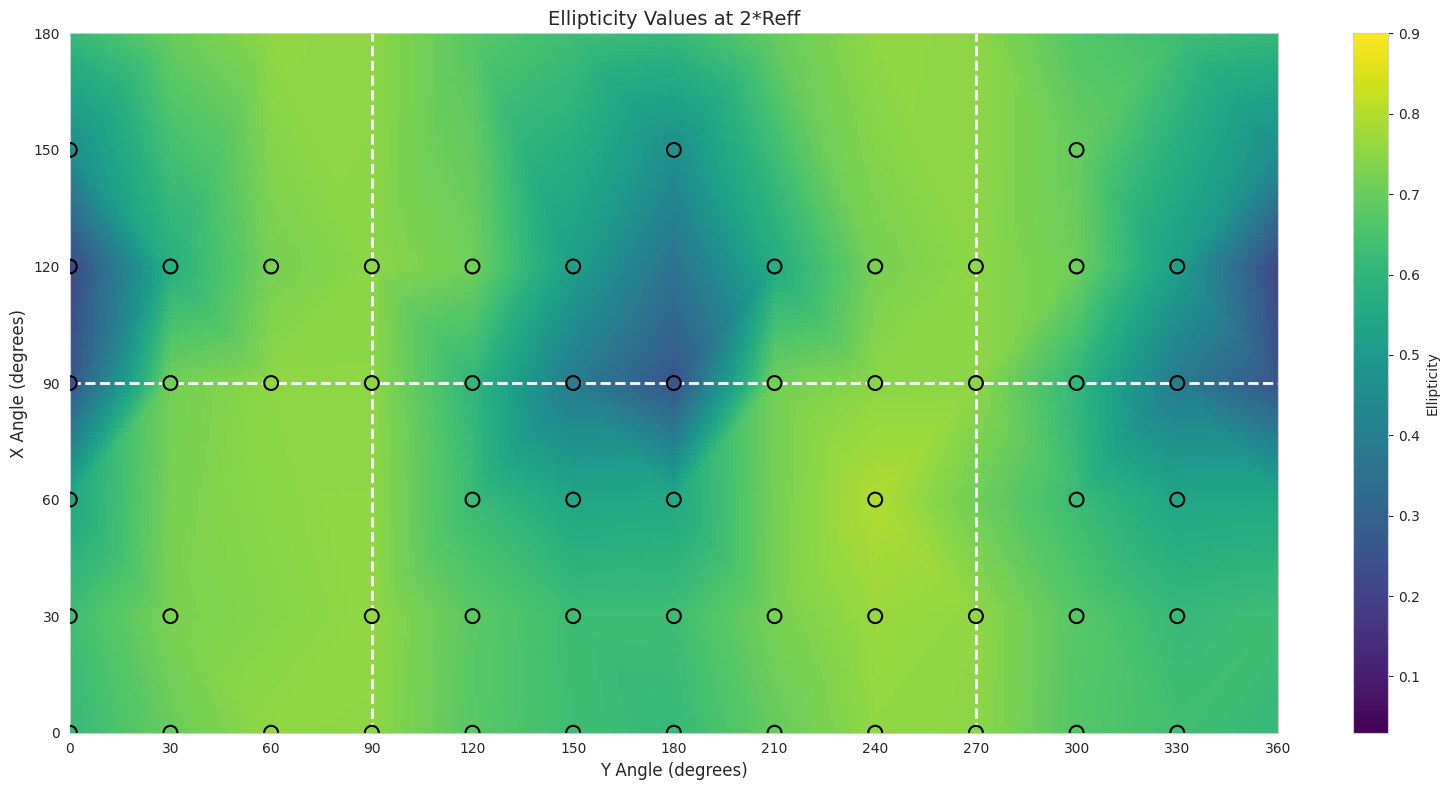

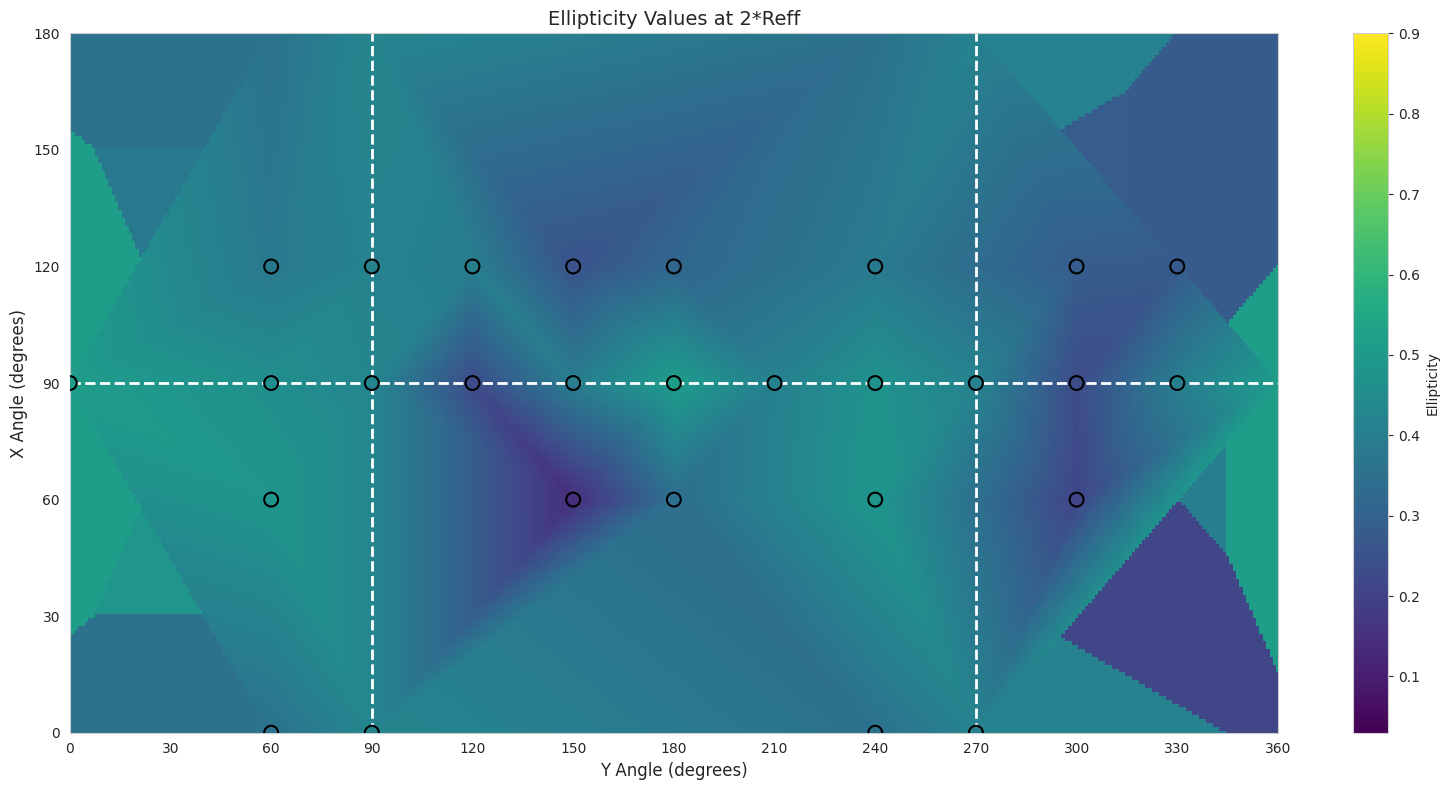

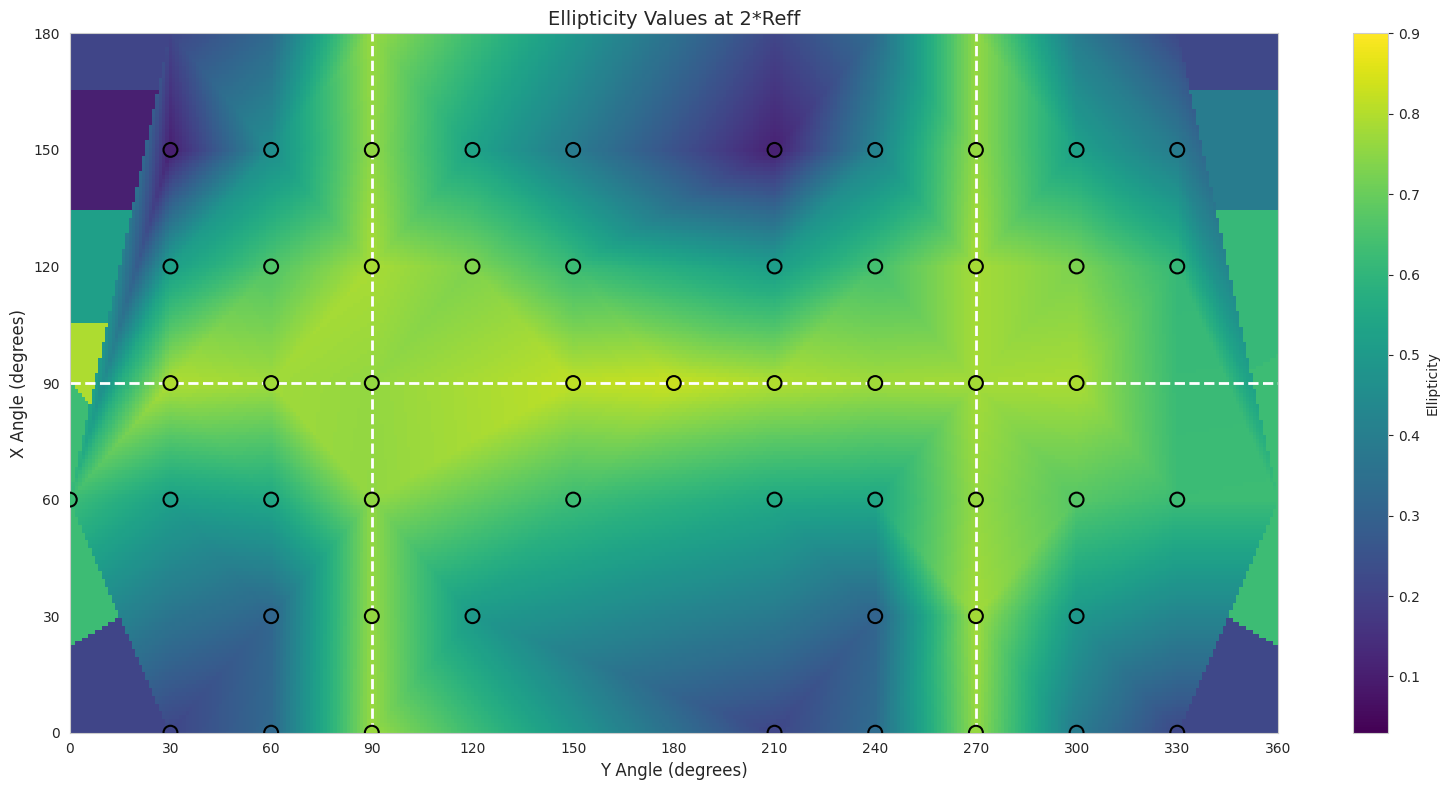

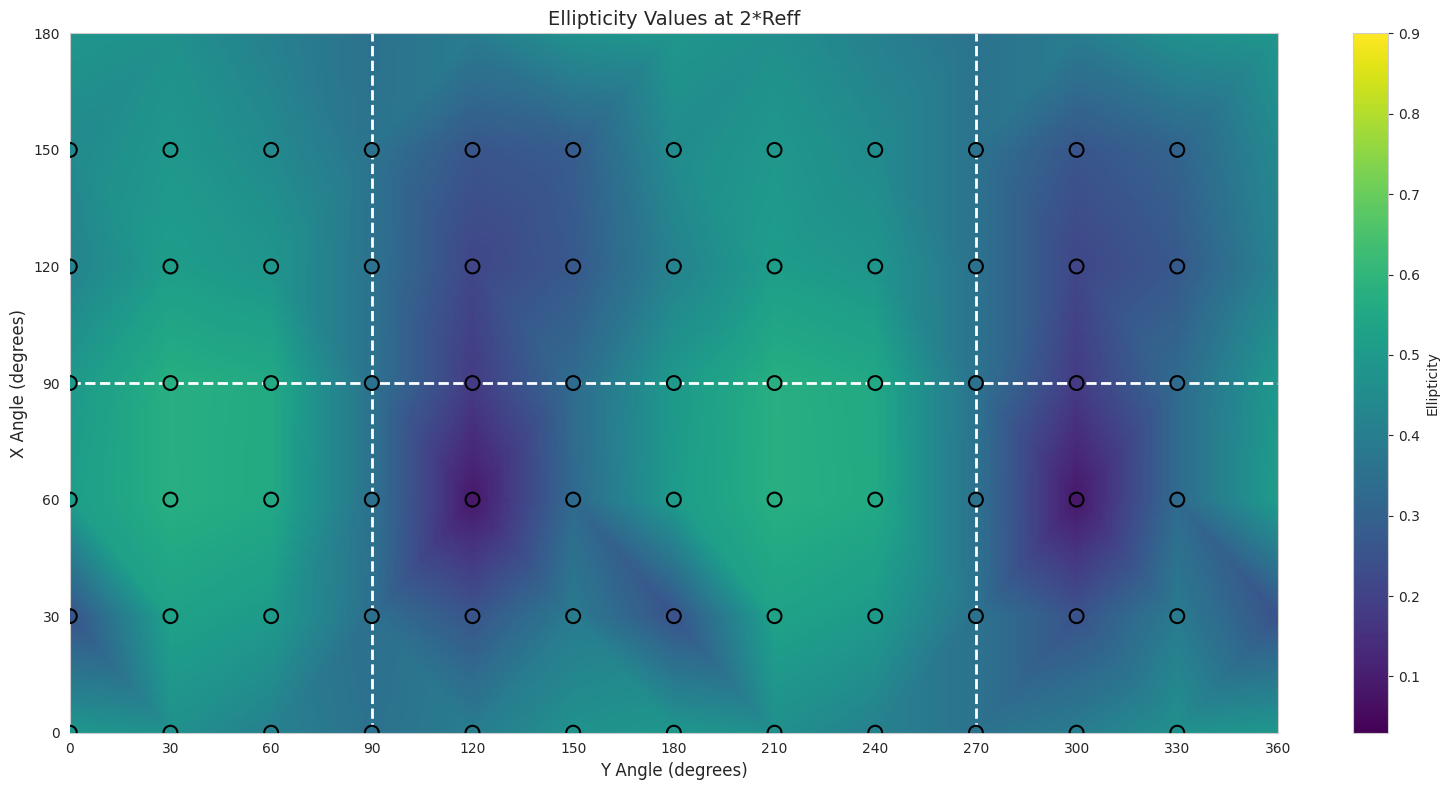

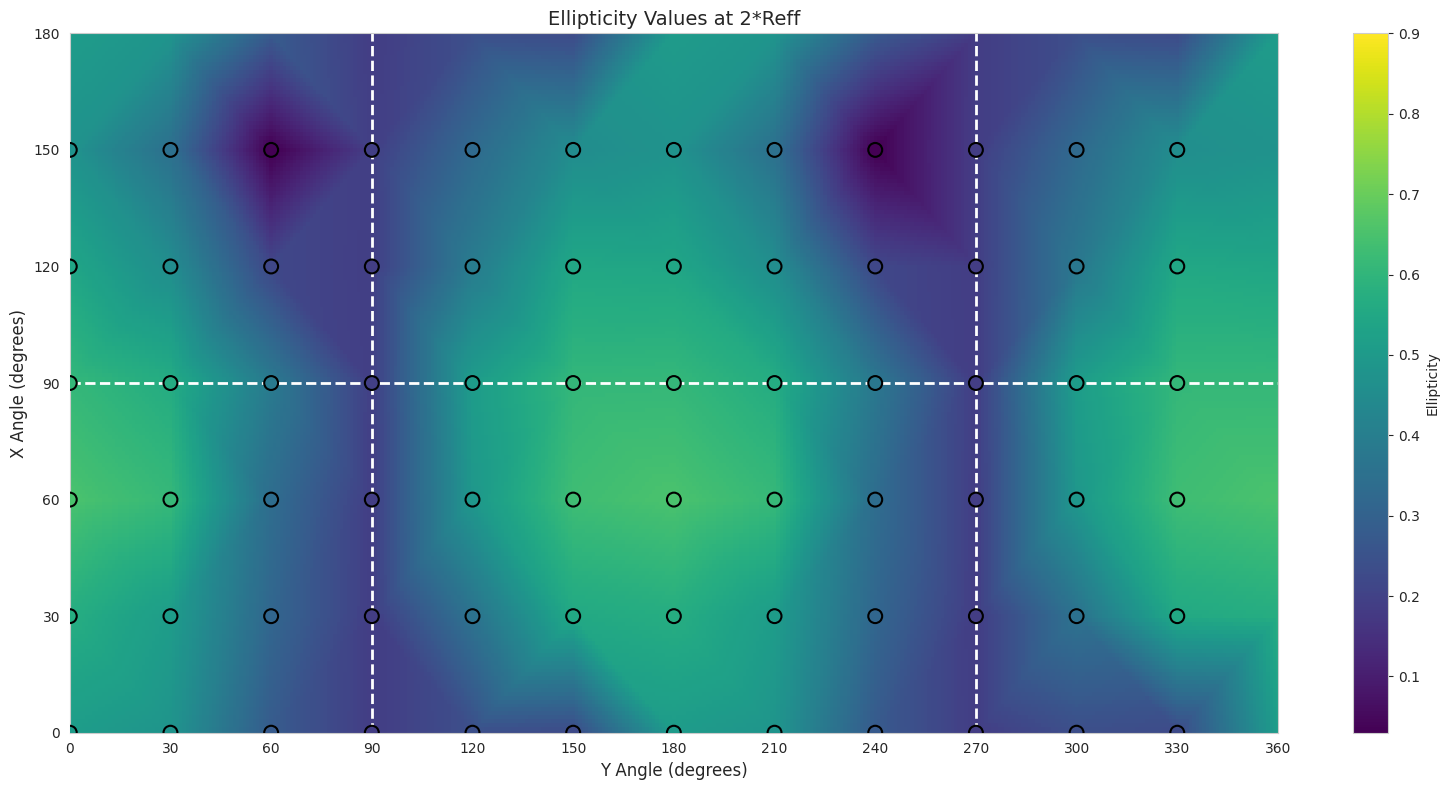

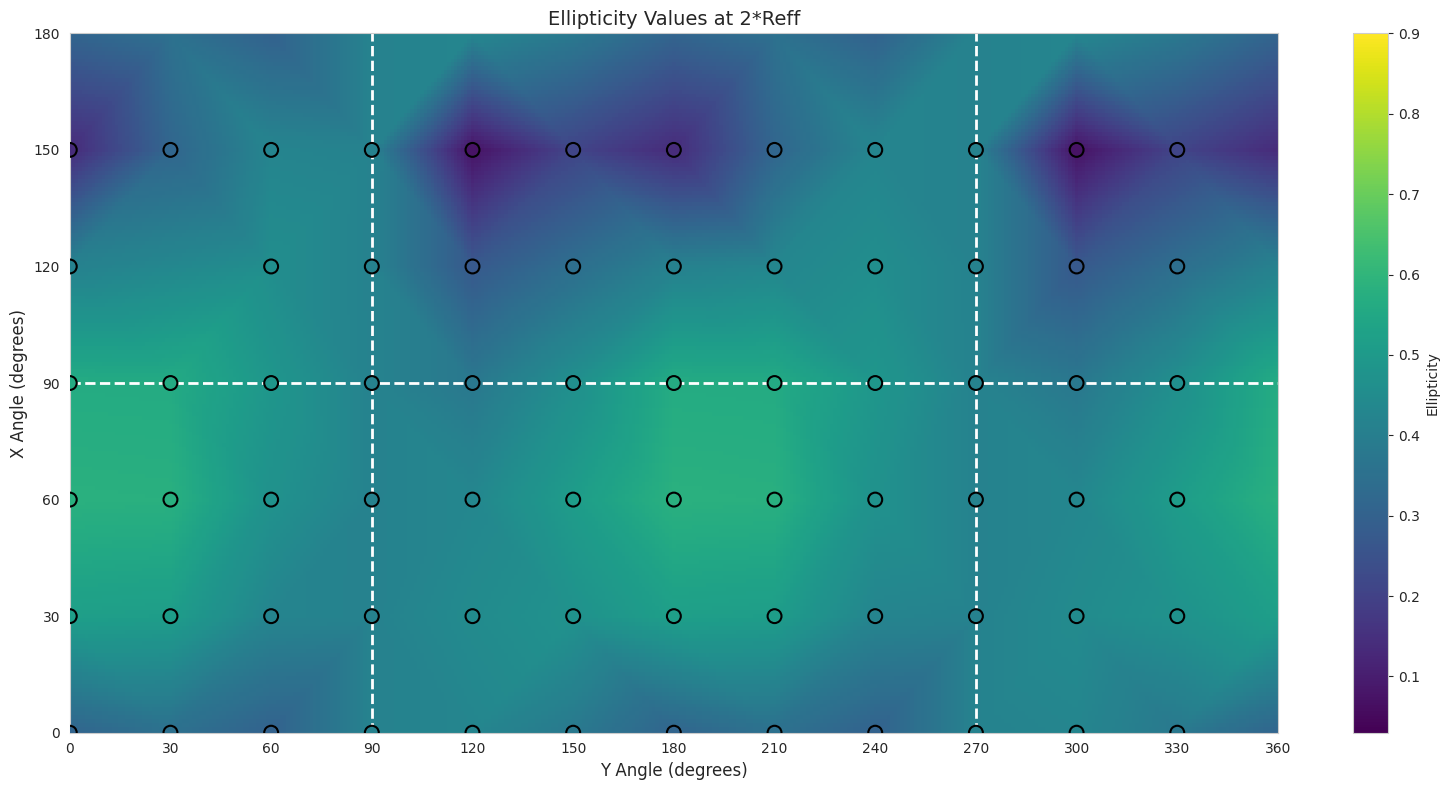

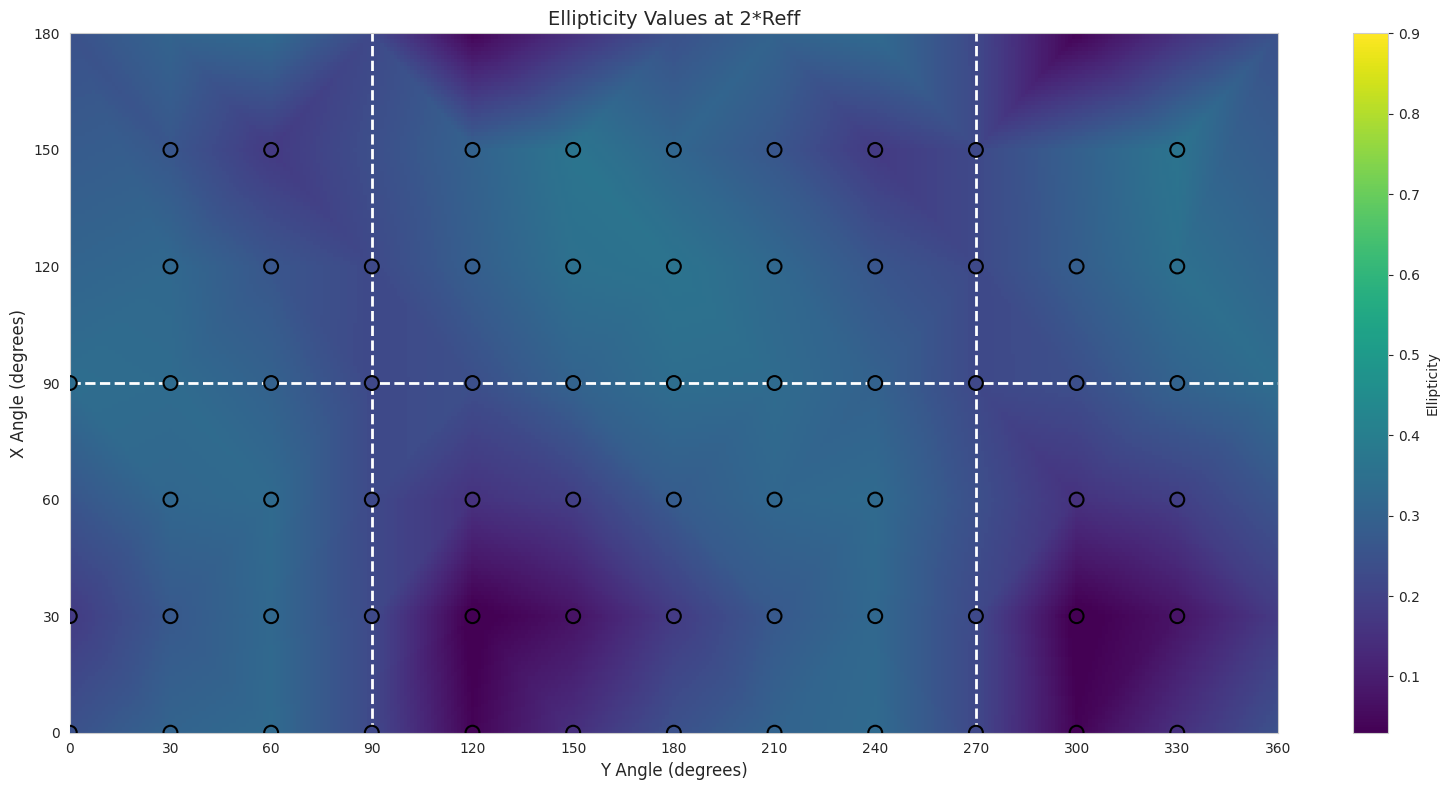

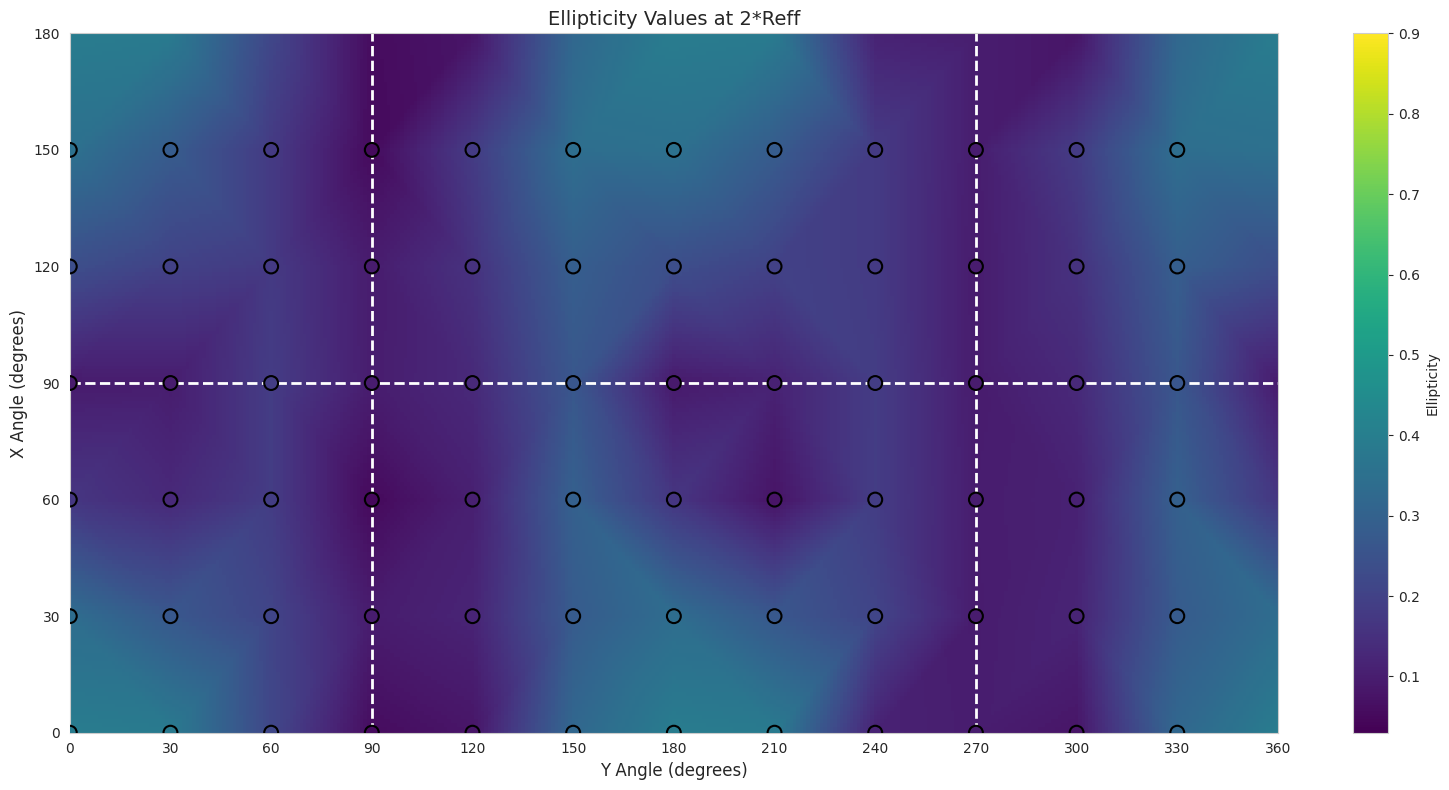

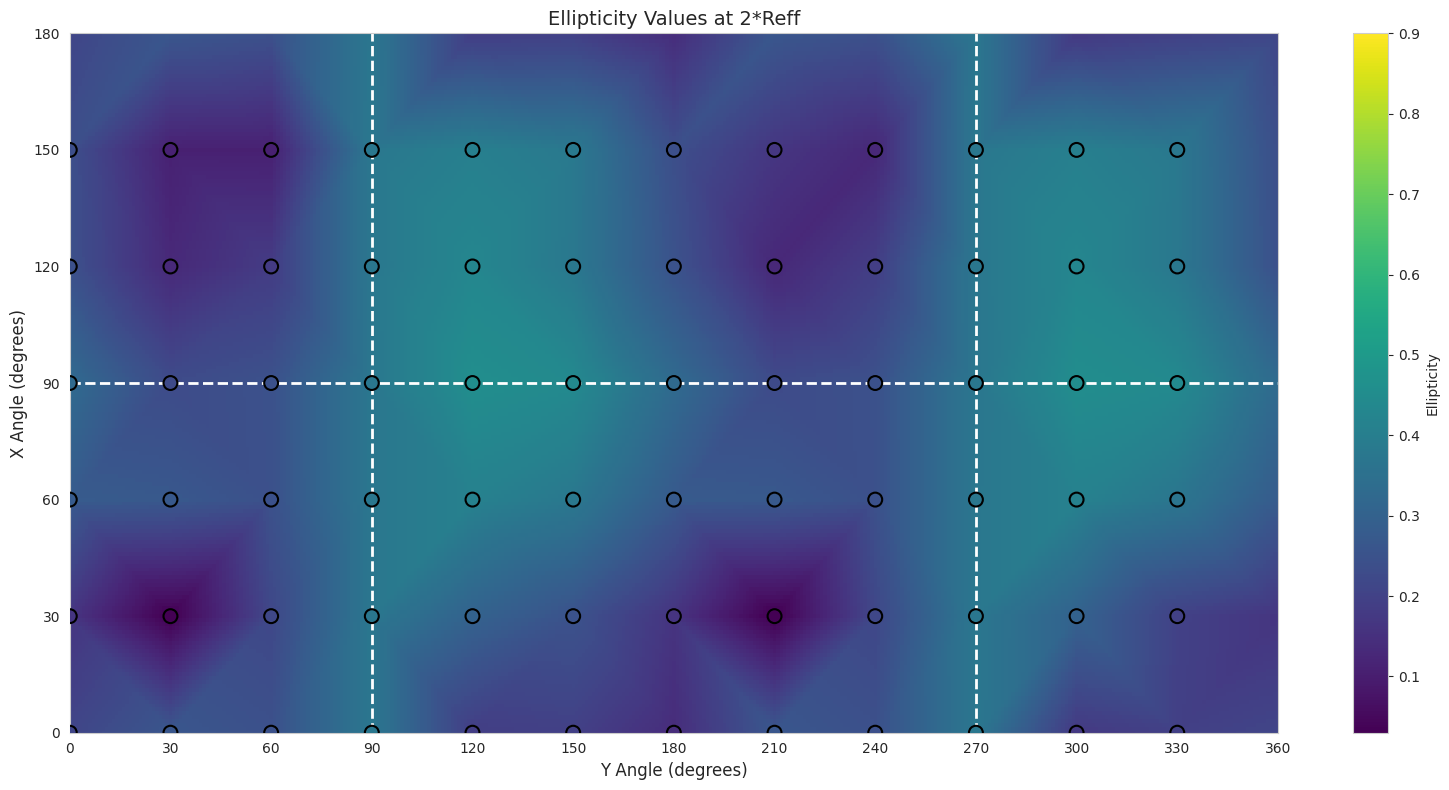

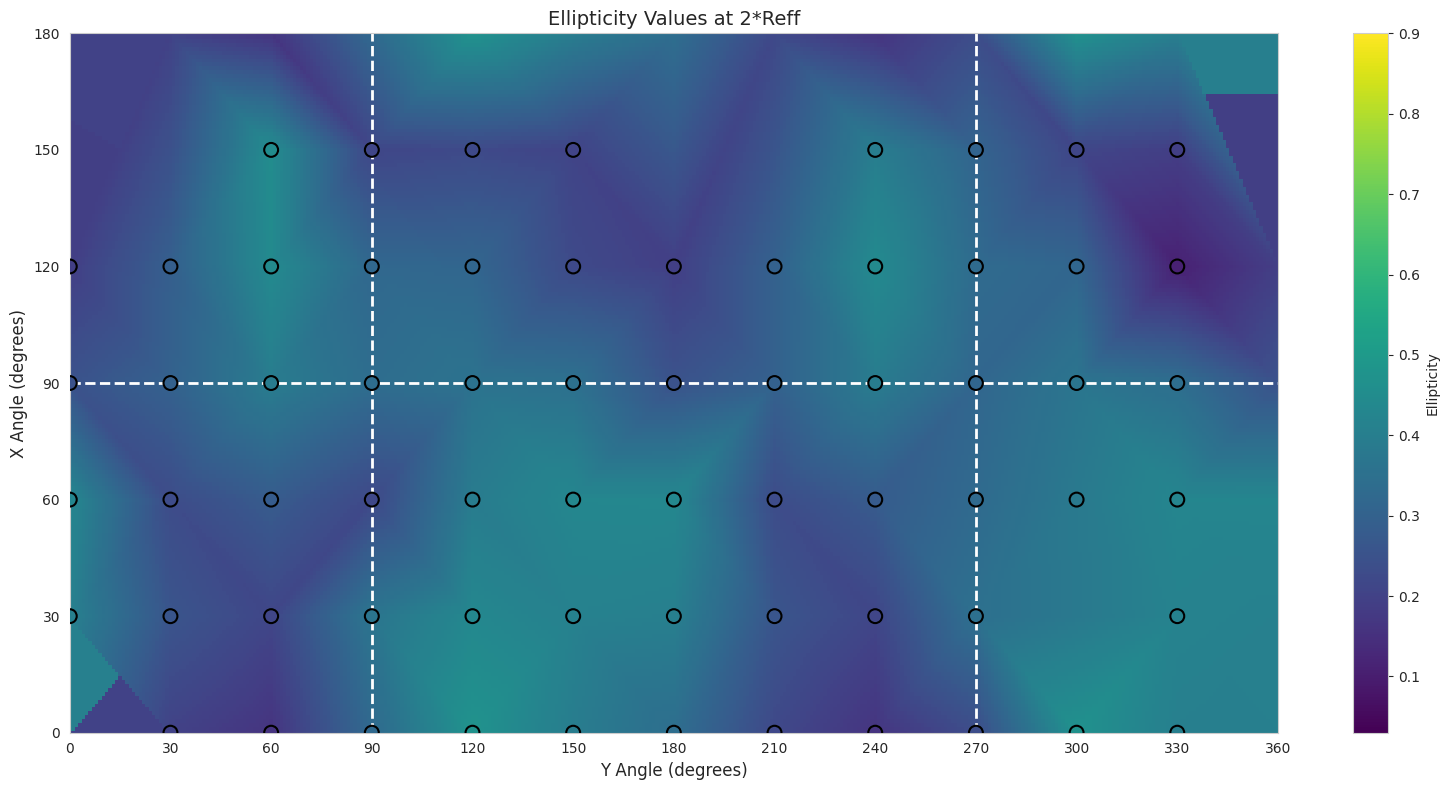

In [15]:
for sim in ellipse_dict.keys():
    for hid in ellipse_dict[sim].keys():
        print(f"Simulation: {sim}, Halo ID: {hid}")
        halo_data = ellipse_dict[sim][hid] 
        #load_and_process_halo_data(sim_name='cptmarvel.cosmo25cmb.4096g5HbwK1BH',halo_id=hid, pickle_filename='ellipse_data.pickle')
        # Create interpolation function with default settings
        interpolate_func, reff_multipliers = interpolate_orientations(
            halo_data, reff_multipliers=[2,3,4],
            interpolation_method='linear',  # Options: 'linear', 'nearest', 'rbf'
            coordinate_system='angles'      # Options: 'angles', 'vectors'
        )
        # Function to format angles as orientation string
        def angle_to_orientation(x_angle, y_angle):
            return f"x{x_angle:03d}y{y_angle:03d}"
        #
        # # Test interpolation
        # print("Interpolation test (linear, angles):")
        # print("Comparing actual data values vs. interpolated values")
        # print("-" * 50)
        #
        # for x_angle, y_angle in [(0, 0),(90,180), (0, 330), (150, 0), (150, 330)]:
        #     print(f"\nx{x_angle:03d}y{y_angle:03d}:")
        #     orientation = angle_to_orientation(x_angle, y_angle)
        #
        #     for i, multiplier in enumerate(reff_multipliers):
        #         if i < len(reff_multipliers):
        #             try:
        #                 # Get interpolated value
        #                 interpolated = interpolate_func(x_angle, y_angle, i)
        #
        #                 # Check if we have actual data for this orientation
        #                 actual_text = "No actual data"
        #                 if orientation in halo_data:
        #                     actual = halo_data[orientation][i]
        #                     actual_text = f"{actual:.4f}"
        #
        #                     # Calculate difference if actual data exists
        #                     diff = interpolated - actual
        #                     diff_percent = (diff / actual) * 100 if actual != 0 else float('inf')
        #
        #                     print(f"  {multiplier}*Reff:  Actual: {actual_text}  Interpolated: {interpolated:.4f}  " +
        #                           f"Diff: {diff:.4f} ({diff_percent:.2f}%)")
        #                 else:
        #                     print(f"  {multiplier}*Reff:  Actual: {actual_text}  Interpolated: {interpolated:.4f}")
        #             except ValueError as e:
        #                 print(f"  {multiplier}*Reff: Error - {e}")
        
        
        
        
        # Create visualization comparing original vs. interpolated values
        plot = plot_ellipticity_comparison(halo_data, interpolate_func,sim,hid, reff_index=0, multiplier=reff_multipliers[0])






In [26]:
ellipse_dict

{'cptmarvel.cosmo25cmb.4096g5HbwK1BH': {0: {'x000y000': array([0.16667868, 0.07946688, 0.04023077]),
   'x000y030': array([0.10740492, 0.0696568 , 0.10616586]),
   'x000y060': array([0.45693582, 0.45156548, 0.37522004]),
   'x000y090': array([0.72453703, 0.64137897, 0.61601037]),
   'x000y120': array([0.39347193, 0.39154378, 0.31999731]),
   'x000y150': array([0.09687204, 0.06201552, 0.04280426]),
   'x000y180': array([0.16685591, 0.07951906, 0.04026203]),
   'x000y210': array([0.10756064, 0.06955032, 0.10077784]),
   'x000y240': array([0.45684904, 0.45153862, 0.37490828]),
   'x000y270': array([0.73739176, 0.64136513, 0.61571928]),
   'x000y300': array([0.3942343 , 0.39153921, 0.32023232]),
   'x000y330': array([0.09596349, 0.06192076, 0.0426177 ]),
   'x030y000': array([0.22386892, 0.17807243, 0.16825411]),
   'x030y030': array([0.35210667, 0.30975945, 0.25346251]),
   'x030y060': array([0.54663956, 0.53297849, 0.46624544]),
   'x030y090': array([0.72465416, 0.64120101, 0.61644383]),

In [35]:
#load pickle file
with open('ellipse_data.pickle', 'rb') as f:
    ellipse_test = pickle.load(f)
    
#try to load elektra.cosmo25cmb.4096g5HbwK1BH halo 3
try:
    halo_data = ellipse_test['elektra.cosmo25cmb.4096g5HbwK1BH'][3]
except KeyError:
    print('KeyError')